# Класс-специфичная задача: подсети классов из парных взаимодействий и мета-модель

Воспроизводится top-down path selection из Ahmad et al. (WACV 2024, далее «статья») - метод строит **класс-специфичный подграф** сети: для каждого класса $k$ узлы, необходимые для логита $z_k$. Здесь для каждого класса из отобранных узлов собирается **маленькая подсеть с одним выходом** (логит класса $k$), затем 10 подсетей объединяются мета-моделью (стекинг), и качество сравнивается **по классам** с подсетями того же размера, полученными из as-is (топ по ATE), по магнитуде и случайно, а также **с исходной сетью**. Датасеты: MNIST и CIFAR-10, по 5 обученных сетей каждого.

**Связь с ноутбуком 1.** Первый ноутбук (`experiment_common_task.ipynb`) прореживает сеть целиком: цепи классов объединяются, и узлы, удалённые правилом для одного класса, могут вернуться через цепь другого. Этот ноутбук проверяет цепи каждого класса **по отдельности**, где такого возврата нет. Теория (интервенции на путях, знак и границы $S$, правило расширения) приведена повторно, чтобы ноутбук читался самостоятельно.

**Как читать.** Раздел 1 - установленные ранее ограничения. Разделы 2-4 - теория и постановка. Раздел 5 - код. Раздел 6 - результаты. Раздел 7 - интерпретация и оценка идеи синергии.

## 1. Что установлено ранее и что нужно учитывать при чтении

Пять выводов из прошлых ноутбуков и отчётов (`experiment3_v2.ipynb`, `experiment5_cifar10.ipynb`, `work/CHECKPOINT_1.md`, `work/FINAL_REPORT.md`); в скобках - где они перепроверяются здесь.

> **1. В малых сетях почти всё помечено как важное - запас для прунинга мал.** В v2 на MNIST критичны 88% каналов `conv2` и 95% фильтров `conv1`, на CIFAR-10 - 53% и 55% (в среднем по классам). Поэтому цепи as-is на уровне класса составляют 15-25% весов (`experiment5`), а не «малые» подсети. *(6.1: размеры цепей)*
>
> **2. На MNIST доля «спасённых» связей мала, поэтому прирост метрик мог быть эффектом насыщения.** *(6.2-6.3: сравнение с подсетями того же размера и после дообучения)*
>
> **3. На CIFAR-10 выигрыш расширения объяснялся размером цепи, а не отбором.** В `experiment5` контроль того же размера (первые узлы по наименьшему ATE) давал AUROC 0.802 против 0.815 у расширения. Поэтому здесь все методы сравниваются **при том же числе узлов на слой, что у расширения для того же класса**. *(6.2-6.3)*
>
> **4. Неаддитивность пар узлов в необученных сетях сопоставима с обученными** («необученная сеть» - сеть той же архитектуры со случайными начальными весами и без обучения). По `work/CHECKPOINT_1.md` зависит от слоя и теста: по строгому тесту с нулевой моделью у необученных доля неаддитивных пар выше в 3 из 4 переходов, в одном (TinyCifarNet `conv1 -> conv2`) выше у обученных. Вывод: неаддитивность в малых сетях не отделена от архитектуры. Контроль на необученной сети выполнен в ноутбуке 1 (раздел 6.7).
>
> **5. Прунинг на основе взаимодействия проигрывает greedy backward по метрикам; стоимость - открытый вопрос.** Greedy backward - метод для сети целиком и в этом ноутбуке не участвует; стоимость подсетей (MAC, задержка, отбор) считается в 6.5.

Общее ограничение: обе сети малы (5.8 тыс. и ~66 тыс. параметров).

In [1]:
# Установка зависимостей в окружение ядра (после установки torch может потребоваться перезапуск ядра)
%pip install -q numpy pandas matplotlib scipy statsmodels torch pyarrow pillow scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: D:\jills projects\.venv\Scripts\python.exe -m pip install --upgrade pip


## 2. Теория: вмешательство на путях (по статье)

**Постановка (раздел 3.2 статьи, уравнение (1)).** Для узла $j$ родительского слоя обнуляются его исходящие веса $w_j^{l\to l+1}$ к выбранному подмножеству дочерних узлов ($n_t < n_c$), затем проверяется нулевая гипотеза $E[TE]=0$ на примерах класса. **Treatment effect (раздел 3.3, определение 1)** - разность логита до softmax при $\beta=0$ и $\beta=1$:
$$TE = z_k(do(w=0)) - z_k(w).$$
**Вмешательство** $u=\beta w$, $\beta\in\{0,1\}$ (в статье допускается и непрерывное $\beta\sim U(b-\epsilon,b+\epsilon)$ только для проверки надёжности, раздел 5.1; здесь используется бинарное). **Path selection (раздел 3.4, Algorithm 1):** идём от выхода к входу и вмешиваемся только в связи с уже отобранными целями следующего уровня; критичными (`critical`) считаются узлы со значимо отрицательным TE, вредными (`harmful`) - со значимо положительным. Тест двусторонний t-тест, $\alpha=0.05$, **без поправки на множественность** (как в статье).

**Почему вмешиваемся в пути, а не выключаем весь канал.** У нейрона может быть полезная связь с одной целью и нерелевантная с другой. Поэтому в статье обнуляются исходящие веса родителя только к выбранным целям: для `conv1 -> conv2` меняется срез `conv2.weight[targets, source]`, а не фильтр `conv1[source]`. При переходе `conv2 -> fc1` один канал `conv2` разворачивается в $s^2$ входов `fc1` (16 у MNIST-сети, 25 у CIFAR-сети), они выключаются единым блоком.

**Дополнительные критерии расширения** (в статье отсутствуют):

* *Поправка на множественность.* Benjamini-Yekutieli вместо BH: парные тесты делят между собой одни и те же величины $TE(A)$ и $TE(B)$, зависимость структурная.
* *Порог размера эффекта.* При $n\approx 10^2$ и малой дисперсии t-тест объявляет значимым эффект в $10^{-3}$ логита, не имеющий содержательного смысла. Поэтому вводится $\tau=\texttt{TAU\_REL}\cdot\mathrm{std}(z_k)$ (std по calibration-примерам класса на неизменённой сети); узел отобран, только если он проходит FDR и $|ATE|>\tau$. Значение фиксируется до просмотра результатов.

t-тест измеряет дисперсию TE **по входам**: нейрон, критичный для половины примеров класса и безразличный для другой половины, может не пройти тест. Поэтому в таблицах узлов хранится и доля примеров с $|TE|>\tau$ (`hit_rate`).

## 3. Теория: парные взаимодействия и правило расширения

Для пары путей $A,B$ потеря логита $L(A)=z_k(\text{original})-z_k(do(A=0))=-TE(A)$, и
$$S(A,B) = L(A\cup B) - L(A) - L(B).$$
Это коэффициент Мёбиуса второго порядка (дивиденд Харсаньи) для функции ценности «ущерб от абляции множества», то есть дискретная смешанная вторая разность; та же величина известна как interaction index второго порядка в теории кооперативных игр. Это **не** синергия в смысле partial information decomposition: мы не разлагаем взаимную информацию активаций, а измеряем нелинейность отклика фиксированной сети на весовые вмешательства.

**Знак $S$.** (Названия из `experiment5`: прежние «комплементарность/избыточность» вводили в заблуждение.)

* $S>0$ - **синергия**: совместное удаление вредит сильнее суммы отдельных удалений. Игрушечный пример: выход $=\max(a,j)$ при $a=j=1$ даёт $L=0,0$ и $L(\{a,j\})=1$, то есть $S=+1$.
* $S<0$ - **субаддитивность**: совместное удаление вредит слабее суммы; узлы делят общую зависимость (выход $=\min(a,j)$ даёт $L=1,1,1$ и $S=-1$).
* $S\approx0$ - аддитивность. Здесь «$S=0$» означает «не значимо после поправки BY при $n=128$ и порога $\tau$».

**Где $S$ может быть ненулевым.** На переходе `fc1 -> fc2` логит $z_k=\sum_j W^{fc2}_{kj}a_j+b_k$ линеен по вмешиваемым весам, поэтому $TE(A\cup B)=TE(A)+TE(B)$ и $S(A,B)\equiv0$ тождественно, с точностью до ошибки округления (в v2 численная проверка дала $\max|S|\sim10^{-6}$). Отсюда общий вывод о границах метода: **ненулевое $S$ может возникнуть только из нелинейностей (ReLU и max-pool) между вмешиваемыми весами и логитом.** Для `conv2 -> fc1` и `conv1 -> conv2` они есть, поэтому парный скрининг проводится только там; на `fc1 -> fc2` действует правило «$S=0$: остаются только `critical`».

**Ограничения.** Проверяются только пары внутри одного слоя. Нулевое парное взаимодействие не означает отсутствия взаимодействий более высокого порядка: три взаимно избыточных канала могут давать $S\approx0$ на каждой паре. Полный парный скрининг стоит $O(n^2)$ прямых проходов на слой.

### Правило расширения (по классу и слою)

Для класса $k$ на каждом слое (сверху вниз, цели следующего слоя равны итогу правила):

1. `critical` узлы (как в статье, но с поправкой BY и порогом $\tau$) попадают в цепь.
2. Пара с $S>0$ (значимо, $|S|>\tau$): **берём оба узла**.
3. Пара с $S<0$: **удаляем узел с меньшим вкладом в логит** ($-ATE$ меньше). Удаление приоритетнее добавления: узел, добавленный по $S>0$ и проигравший по $S<0$, удаляется (сигнал, что метка `critical` этого узла недостоверна). Удаления применяются **по убыванию $|S|$ и только пока оба узла пары ещё в цепи**: иначе цепочка $A>B>C$ удалила бы и $B$, и $C$, хотя $C$ избыточен только с уже удалённым $B$.
4. Пара с $S=0$ (в том числе все узлы на `fc1 -> fc2`): остаются только `critical`.
5. В слое всегда остаётся не менее одного узла (самый сильный по $-ATE$), иначе цепь пуста.

Знак вклада: $-ATE$ учитывает знак, поэтому `harmful` узел (ATE > 0) удаляется раньше `critical`. Для двух `critical` узлов это то же, что «меньший $|ATE|$».

Число добавленных (по $S>0$), удалённых (по $S<0$) и конфликтных узлов выводится как диагностика (раздел 6.2); отдельных «алгоритмов только добавления» и «только удаления» нет.

## 4. Постановка эксперимента

**Подсеть класса.** Для класса $k$ (метод $M$) получен набор узлов $\{J_{conv1}, J_{conv2}, J_{fc1}\}$. Подсеть - плотная сеть из этих узлов и **всех** связей между ними, с одним выходом: строкой `fc2[k, J_{fc1}]`. Для цепи одного класса такая подсеть совпадает с маской путей v2 (объединение прямоугольников появляется только при объединении классов), поэтому здесь вопрос «узлы или пути» не возникает. Подсеть физически меньше (меньше каналов и нейронов), MAC и время измеряются напрямую.

**Методы (одинаковое число узлов на слой для одного класса):**

| Метод | Как выбираются узлы слоя (top-down: цели слоя = выбранные узлы слоя выше) |
|---|---|
| `расширение (синергия)` | правило по знаку $S$ из раздела 3 (BY, $\tau$; $S>0$ - оба, $S<0$ - удаляем меньший вклад, $S=0$ - только `critical`) |
| `as-is (топ-ATE)` | узлы с наибольшим вкладом в логит ($-ATE$) относительно текущих целей, значимость не требуется; число узлов = число узлов расширения на этом слое |
| `магнитуда (пути)` | узлы с наибольшей нормой исходящих весов к текущим целям (тот же top-down проход, но критерий по весам, а не по эффекту) |
| `случайный (узлы)` | случайные узлы слоя (5 розыгрышей на класс) |
| `as-is (естественный размер)` | цепь Algorithm 1 без изменений (свой размер, справочно) |

Так контролируется размер цепи (ограничение 3): расширение и контроли отличаются только критерием выбора узлов.

**Мета-модель (стекинг, Wolpert 1992).** Каждая подсеть даёт один логит; 10 логитов образуют признаки, на которых обучается многоклассовая логистическая регрессия (стандартизация, $L_2$, $C$ по 5-кратной кросс-валидации). Мета-модель обучается на **мета-выборке**, не пересекающейся ни с обучающей частью сети, ни с sel-частью (откуда берутся примеры для t-тестов), ни с тестом: логиты подсетей на обучающих картинках были бы смещены, а sel-примеры выбраны только из правильно классифицированных. Мета-модель выравнивает масштабы логитов разных подсетей (после маскирования они не сопоставимы), поэтому таблицы содержат и accuracy без мета-модели (argmax логитов). Для справки: исходная сеть, тот же мета-алгоритм на её 10 логитах.

**Без дообучения и с дообучением.** Без дообучения подсеть - вырезка из исходной сети (как в статье, раздел 6: метод «отличается от прунинга, который требует дообучения»). С дообучением: маска фиксирована структурно, подсеть 3 эпохи обучается на обучающей части бинарной кросс-энтропией на своём логите с весом положительного класса 9 (без баланса классов 1:9 и при меньшем lr подсети схлопывались: на отладочном запуске AUROC класса 8 падал с 0.74 до 0.44), lr $10^{-3}$.

**Необходимость (протокол Fig. 10 статьи, раздел 5.3).** В полной сети маскируется доля $p\in\{10,\dots,50\}\%$ узлов цепи класса $k$ (топ по вкладу), измеряются падение recall класса (должно быть большим) и падение accuracy на остальных классах (побочный ущерб). Сравнение с удалением того же числа узлов по магнитуде путей и случайных узлов. В отличие от v2 удаляется не вся схема, а её доля: полное удаление превращает сеть в константный классификатор и ничего не различает.

**Выигрыш относительно исходной сети определяется заранее по трём измерениям**, потому что при равных метриках качества единственная причина использовать подсети - стоимость: (а) качество по классам и в целом против исходной сети; (б) число параметров и MAC подсети; (в) измеренная задержка компактной сети. Рассматриваются три сценария: **один класс** («это класс $k$?»: сравнивается одна подсеть с исходной сетью), **10-классовая классификация через стекинг** (10 подсетей подряд: если каждая составляет 20-25% сети, в сумме стоимость может превысить стоимость исходной сети), **объединение узлов** (общие узлы вычисляются один раз, но это уже прунинг сети целиком, как в ноутбуке 1).

**Метрики (все на тесте).** Подсеть: AUROC логита «класс против остальных» (не зависит от порога и масштаба), average precision, корреляция логита с логитом исходной сети. Стекинг: accuracy, macro-F1, recall и F1 по классам. Сравнение - **парное по (класс, сеть)**: разность расширения с контролем и число побед из 50 пар (10 классов $\times$ 5 сетей); случайные подсети усреднены по розыгрышам. Все пороги и гиперпараметры зафиксированы до просмотра результатов.

## 5. Код

Ячейки ниже используют тот же код отбора, что ноутбук 1 (данные, сеть, интервенции, правило, компактная сеть), и добавляют подсети классов, мета-модель, необходимость и стоимость. Результаты кэшируются в `cache/class/`; отобранные цепи и обученные сети берутся из `cache/common/`, если ноутбук 1 уже запускался, иначе считаются здесь.

In [2]:
# 0. Окружение, конфигурация, данные, модель
import sys, os, gzip, struct, io, time, pickle, random, warnings, shutil
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass
from itertools import combinations
from typing import Optional
from urllib.request import Request, urlopen, urlretrieve
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import torch, torch.nn as nn, torch.nn.functional as F
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)    # предупреждения sklearn о будущих изменениях API
warnings.filterwarnings('ignore', category=RuntimeWarning)   # t-тест на константном векторе (мёртвый узел) даёт nan, ниже он обрабатывается явно

# --- Конфигурация. Все пороги фиксируются здесь, до просмотра результатов. ---
QUICK       = os.environ.get('NB_QUICK') == '1'      # быстрый режим для отладки: 1 сеть, 1 датасет
SEEDS       = [42] if QUICK else [42, 0, 1, 2, 3]    # 5 независимых обучений сети на датасет
DATASETS    = os.environ['NB_DATASETS'].split(',') if os.environ.get('NB_DATASETS') else (['MNIST'] if QUICK else ['MNIST', 'CIFAR-10'])
ALPHA       = 0.05        # уровень значимости, как в статье
FDR_METHOD  = 'fdr_by'    # Benjamini-Yekutieli: парные тесты структурно зависимы
TAU_REL     = 0.02        # порог размера эффекта, в долях std логита класса
N_CAL       = 128         # правильно классифицированных примеров на класс для t-тестов
N_RANDOM    = 3 if QUICK else 20     # розыгрышей случайной линии без дообучения
N_RANDOM_FT = 1 if QUICK else 2      # розыгрышей случайной линии с дообучением
FT_EPOCHS   = 1 if QUICK else 3      # эпох дообучения при фиксированной маске
FT_LR       = 5e-4
CACHE_DIR   = Path('cache/common'); CACHE_DIR.mkdir(parents=True, exist_ok=True)
USE_CACHE   = True        # результаты (сеть, цепи, таблицы) на диске: повторный запуск не пересчитывает отбор

random.seed(42); np.random.seed(42); torch.manual_seed(42)
torch.use_deterministic_algorithms(True, warn_only=True)
device = torch.device('cpu')
torch.set_num_threads(4)
print('Python:', sys.executable); print('Device:', device, '| QUICK =', QUICK, '| seeds:', SEEDS, '| datasets:', DATASETS)

# Разбиение данных: обучение сети / отбор путей и greedy / обучение мета-модели (ноутбук 2) / тест. Тест не участвует ни в чём, кроме итоговых метрик.
DS = {
    'MNIST':    dict(in_ch=1, size=28, widths=(6, 10, 24),  s=4, n_train=12000, n_sel=8000, n_meta=10000, epochs=6,  greedy_n=1000, greedy_steps=36),
    'CIFAR-10': dict(in_ch=3, size=32, widths=(16, 32, 64), s=5, n_train=40000, n_sel=5000, n_meta=5000,  epochs=10, greedy_n=600,  greedy_steps=90),
}
if QUICK: DS['MNIST']['greedy_steps'] = 6
CLASS_NAMES = {'MNIST': [str(i) for i in range(10)],
               'CIFAR-10': ['самолёт', 'автомобиль', 'птица', 'кошка', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']}

def _load_mnist():
    root = Path('data/mnist_raw'); root.mkdir(parents=True, exist_ok=True)
    base = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
    files = {'tr_x': 'train-images-idx3-ubyte.gz', 'tr_y': 'train-labels-idx1-ubyte.gz', 'te_x': 't10k-images-idx3-ubyte.gz', 'te_y': 't10k-labels-idx1-ubyte.gz'}
    for f in files.values():
        if not (root / f).exists(): urlretrieve(base + f, root / f)
    def img(p):
        with gzip.open(root / p, 'rb') as f:
            _, n, r, c = struct.unpack('>IIII', f.read(16)); return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, 1, r, c).copy()
    def lab(p):
        with gzip.open(root / p, 'rb') as f:
            f.read(8); return np.frombuffer(f.read(), dtype=np.uint8).astype(np.int64).copy()
    return img(files['tr_x']), lab(files['tr_y']), img(files['te_x']), lab(files['te_y'])

def _load_cifar():
    root = Path('data/cifar10_raw'); root.mkdir(parents=True, exist_ok=True); npz = root / 'cifar10_u8.npz'
    if not npz.exists():
        from PIL import Image
        base = 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/'
        out = {}
        for split, name in [('train', 'train-00000-of-00001.parquet'), ('test', 'test-00000-of-00001.parquet')]:
            path = root / f'cifar10_{split}.parquet'
            if not path.exists():
                with urlopen(Request(base + name, headers={'User-Agent': 'Mozilla/5.0'}), timeout=120) as r, open(path, 'wb') as f: shutil.copyfileobj(r, f)
            df = pd.read_parquet(path)
            out[f'x_{split}'] = np.ascontiguousarray(np.stack([np.array(Image.open(io.BytesIO(d['bytes'])).convert('RGB')) for d in df['img']]).transpose(0, 3, 1, 2))
            out[f'y_{split}'] = df['label'].to_numpy(dtype=np.int64)
        np.savez(npz, **out)
    z = np.load(npz); return z['x_train'], z['y_train'], z['x_test'], z['y_test']

class Data:
    """Изображения хранятся как uint8 и нормируются по батчам (экономия памяти на CPU)."""
    MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1); STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)
    def __init__(self, name):
        self.name, self.cfg = name, DS[name]
        xtr, ytr, xte, yte = _load_mnist() if name == 'MNIST' else _load_cifar()
        self.xtr, self.ytr, self.xte, self.yte = map(torch.from_numpy, (xtr, ytr, xte, yte))
        c = self.cfg; perm = torch.randperm(len(self.ytr), generator=torch.Generator().manual_seed(42))
        a, b, d = c['n_train'], c['n_train'] + c['n_sel'], c['n_train'] + c['n_sel'] + c['n_meta']
        self.train_idx, self.sel_idx, self.meta_idx = perm[:a], perm[a:b], perm[b:d]
        self.classes = CLASS_NAMES[name]
    def prep(self, xu8):
        x = xu8.float().div_(255)
        return x if self.name == 'MNIST' else (x - self.MEAN) / self.STD
    def x_train(self, idx): return self.prep(self.xtr[idx])
    def y_train(self, idx): return self.ytr[idx]

class ConvNet(nn.Module):
    """conv1 -> pool -> conv2 -> pool -> fc1 -> fc2. Ширины (c1, c2, f1) параметризованы, чтобы собирать компактные сети после удаления узлов."""
    def __init__(self, in_ch, widths, s, n_out=10):
        super().__init__(); c1, c2, f1 = widths; self.s = s
        self.conv1 = nn.Conv2d(in_ch, c1, 5); self.conv2 = nn.Conv2d(c1, c2, 5)
        self.fc1 = nn.Linear(c2 * s * s, f1); self.fc2 = nn.Linear(f1, n_out)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2); x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        return self.fc2(F.relu(self.fc1(x.flatten(1))))

def new_net(data, widths=None, n_out=10, seed=None):
    if seed is not None: torch.manual_seed(seed)
    return ConvNet(data.cfg['in_ch'], widths or data.cfg['widths'], data.cfg['s'], n_out).to(device)

def train_net(net, data, epochs, lr, seed, loss_fn=None, target=None):
    """Обучение на train-части. Используется и для исходной сети, и для дообучения компактных сетей (маска фиксирована структурно)."""
    g = torch.Generator().manual_seed(seed); opt = torch.optim.Adam(net.parameters(), lr=lr); idx = data.train_idx
    for _ in range(epochs):
        net.train(); order = torch.randperm(len(idx), generator=g)
        for i in range(0, len(idx), 128):
            b = idx[order[i:i + 128]]; xb, yb = data.x_train(b), data.y_train(b)
            opt.zero_grad(); out = net(xb)
            loss = F.cross_entropy(out, yb) if loss_fn is None else loss_fn(out, (yb == target).float())
            loss.backward(); opt.step()
    return net.eval()

@torch.no_grad()
def logits_on(net, xu8, data, batch=2500):
    net.eval(); return torch.cat([net(data.prep(xu8[i:i + batch])) for i in range(0, len(xu8), batch)])

def build_and_train(data, seed):
    net = new_net(data, seed=seed)
    return train_net(net, data, data.cfg['epochs'], 1e-3, seed)

Python: D:\jills projects\.venv\Scripts\python.exe
Device: cpu | QUICK = False | seeds: [42, 0, 1, 2, 3] | datasets: ['MNIST', 'CIFAR-10']


In [3]:
# 1. Path-интервенции (Algorithm 1 статьи) и правило расширения по знаку взаимодействия S
METER = {'images': 0}                      # счётчик прямых проходов по изображениям: аппаратно-независимая мера стоимости отбора
def fwd(net, x):
    METER['images'] += len(x); return net(x)

def stages_for(cfg):
    """(parent, child, n_parent, spatial_block, nonlinear_after). fc1 -> fc2: логит линеен по fc2.weight[k, :], значит S = 0 тождественно."""
    c1, c2, f1 = cfg['widths']; s2 = cfg['s'] ** 2
    return [('fc1', 'fc2', f1, None, False), ('conv2', 'fc1', c2, s2, True), ('conv1', 'conv2', c1, None, True)]

def module_of(net, name): return dict(net.named_modules())[name]

@torch.no_grad()
def logits_with_removed_paths(net, x, interventions):
    """do(w=0) для групп исходящих путей узла к выбранным целям, с полным восстановлением весов (β=0, как в Algorithm 1)."""
    backups = []
    try:
        for parent, child, source, targets, block in interventions:
            w = module_of(net, child).weight; targets = list(targets)
            index = (targets, source) if block is None else (targets, slice(source * block, (source + 1) * block))
            backups.append((w, index, w[index].detach().clone())); w[index] = 0
        return fwd(net, x)
    finally:
        for w, index, saved in reversed(backups): w[index] = saved

def fdr(rows, alpha, method):
    """method=None: статья as-is (сырое p < alpha, без поправки на множественность). 'fdr_by': расширение."""
    if not rows: return rows
    if method is None:
        for r in rows: r['p_fdr'], r['significant'] = float(r['p']), bool(r['p'] < alpha)
        return rows
    reject, p_adj, _, _ = multipletests([r['p'] for r in rows], alpha=alpha, method=method)
    for r, ok, p in zip(rows, reject, p_adj): r['p_fdr'], r['significant'] = float(p), bool(ok)
    return rows

def mean_test(values, tau):
    _, p = stats.ttest_1samp(values, 0.0)
    return {'ate': float(np.mean(values)), 'std': float(np.std(values, ddof=1)), 'p': float(np.nan_to_num(p, nan=1.0)), 'hit_rate': float(np.mean(np.abs(values) > tau))}

@torch.no_grad()
def calib_examples(net, data, class_id, n=N_CAL, seed=42, require_correct=True):
    """Случайные примеры класса из sel-части (не из теста). Для обученной сети - только правильно классифицированные (как в статье)."""
    cand = data.sel_idx[data.ytr[data.sel_idx] == class_id]
    if require_correct:
        cand = cand[logits_on(net, data.xtr[cand], data).argmax(1) == class_id]
    if len(cand) < 16: raise RuntimeError(f'Мало примеров класса {class_id}: {len(cand)}')
    pick = torch.randperm(len(cand), generator=torch.Generator().manual_seed(seed + class_id))[:n]
    return data.prep(data.xtr[cand[pick]])

@dataclass(frozen=True)
class AlgoConfig:
    """correction: None - как в статье; 'fdr_by' - расширение. tau_rel: порог размера эффекта (0 - выключен, как в статье).
    pair_screen: парный скрининг S и правило по знаку (расширение, в статье отсутствует)."""
    name: str
    correction: Optional[str] = None
    tau_rel: float = 0.0
    pair_screen: bool = False
    alpha: float = ALPHA

PAPER_ASIS = AlgoConfig('as-is', correction=None, tau_rel=0.0, pair_screen=False)
EXT        = AlgoConfig('ext',   correction=FDR_METHOD, tau_rel=TAU_REL, pair_screen=True)

def apply_sign_rule(ate, critical, pairs):
    """Правило расширения для одного класса и одного слоя.
       S>0 (синергия): берём оба узла.  S<0 (субаддитивность): удаляем узел с меньшим вкладом в логит (вклад = -ATE).
       S=0 (аддитивность): остаётся только critical.
       Конфликт (узел добавлен по S>0 и проигрывает по S<0): удаление приоритетнее добавления.
       Удаления идут по убыванию |S| и только пока ОБА узла пары ещё в цепи: иначе цепочка A>B>C удалила бы и B, и C,
       хотя C избыточен лишь с уже удалённым B."""
    syn_nodes = {n for r in pairs if r['sign'] == 'synergy' for n in (r['a'], r['b'])}
    keep = set(critical) | syn_nodes; removed = []
    for r in sorted([r for r in pairs if r['sign'] == 'subadditive'], key=lambda r: -abs(r['S'])):
        a, b = r['a'], r['b']
        if a not in keep or b not in keep: continue
        la, lb = -ate[a], -ate[b]
        loser = a if (la < lb or (la == lb and a > b)) else b       # меньший вклад в логит; при равенстве - больший индекс
        keep.discard(loser); removed.append(loser)
    added = syn_nodes - set(critical)
    return sorted(keep), sorted(syn_nodes), sorted(added), sorted(removed), sorted(set(removed) & syn_nodes)

def infer_class(net, data, class_id, algo, require_correct=True):
    """Top-down восстановление причинного подграфа одного класса: fc1 -> fc2, conv2 -> fc1, conv1 -> conv2.
    algo=PAPER_ASIS - Algorithm 1 as-is. algo=EXT - плюс поправка BY, порог tau и правило по знаку S."""
    net.eval(); stages = stages_for(data.cfg); x = calib_examples(net, data, class_id, require_correct=require_correct)
    with torch.no_grad(): baseline = fwd(net, x)[:, class_id].cpu().numpy()
    tau = algo.tau_rel * float(np.std(baseline, ddof=1)); targets, out = [class_id], []
    for parent, child, n_parent, block, nonlinear in stages:
        singles, te_cache = [], {}
        for s in range(n_parent):
            te = logits_with_removed_paths(net, x, [(parent, child, s, tuple(targets), block)])[:, class_id].cpu().numpy() - baseline
            te_cache[s] = te; singles.append(mean_test(te, tau))
        fdr(singles, algo.alpha, algo.correction)
        ate = np.array([r['ate'] for r in singles])
        for r in singles:
            keep_ = r['significant'] and abs(r['ate']) > tau
            r['role'] = 'critical' if keep_ and r['ate'] < 0 else 'harmful' if keep_ and r['ate'] > 0 else 'neutral'
        critical = [s for s, r in enumerate(singles) if r['role'] == 'critical']; harmful = [s for s, r in enumerate(singles) if r['role'] == 'harmful']
        pairs = []
        if algo.pair_screen and nonlinear:
            for a, b in combinations(range(n_parent), 2):
                te_j = logits_with_removed_paths(net, x, [(parent, child, a, tuple(targets), block), (parent, child, b, tuple(targets), block)])[:, class_id].cpu().numpy() - baseline
                r = mean_test(-te_j + te_cache[a] + te_cache[b], tau); r.update(a=a, b=b, S=r['ate']); pairs.append(r)   # S = L(A+B) - L(A) - L(B), L = -TE
            fdr(pairs, algo.alpha, algo.correction)
            for r in pairs:
                ok = r['significant'] and abs(r['S']) > tau
                r['sign'] = 'synergy' if ok and r['S'] > 0 else 'subadditive' if ok and r['S'] < 0 else 'additive'
        if algo.pair_screen:
            chosen, syn_nodes, added, removed, conflict = apply_sign_rule(ate, critical, pairs)
        else:
            chosen, syn_nodes, added, removed, conflict = list(critical), [], [], [], []
        if not chosen: chosen = [int(np.argmin(ate))]            # не менее одного узла на слой, иначе цепь пуста
        out.append({'parent': parent, 'child': child, 'targets': tuple(targets), 'n_parent': n_parent, 'ate': ate,
                    'p_fdr': np.array([r['p_fdr'] for r in singles]), 'critical': critical, 'harmful': harmful,
                    'synergy_nodes': syn_nodes, 'added': added, 'removed': removed, 'conflict': conflict,
                    'n_pairs': len(pairs), 'n_syn': sum(r['sign'] == 'synergy' for r in pairs), 'n_sub': sum(r['sign'] == 'subadditive' for r in pairs),
                    'pair_S': np.array([r['S'] for r in pairs], dtype=np.float32), 'pair_sign': [r['sign'] for r in pairs],
                    'chosen': chosen})
        targets = chosen
    return {'class': class_id, 'algo': algo.name, 'tau': tau, 'stages': out}

def infer_all(net, data, algo, classes=range(10), require_correct=True):
    """Цепи всех классов + стоимость отбора (прямые проходы по изображениям и секунды)."""
    METER['images'] = 0; t0 = time.perf_counter()
    circ = {c: infer_class(net, data, c, algo, require_correct) for c in classes}
    return circ, {'images': METER['images'], 'seconds': time.perf_counter() - t0}

In [4]:
# 2. Единица прунинга - УЗЕЛ. Наборы узлов, компактная сеть, размер, базовые методы, greedy backward, оценка
LAYERS3 = ['conv1', 'conv2', 'fc1']            # прореживаемые слои: фильтры conv1, каналы conv2, нейроны fc1 (выходной слой fc2 сохраняется)

def full_counts(cfg): return dict(zip(LAYERS3, cfg['widths']))

def eff_weights(cfg, counts, n_out=10):
    """Число весов плотной сети из оставленных узлов (без bias)."""
    s2 = cfg['s'] ** 2
    return {'conv1': counts['conv1'] * cfg['in_ch'] * 25, 'conv2': counts['conv2'] * counts['conv1'] * 25,
            'fc1': counts['fc1'] * counts['conv2'] * s2, 'fc2': n_out * counts['fc1']}

def macs(cfg, counts, n_out=10):
    ho1 = cfg['size'] - 4; ho2 = ho1 // 2 - 4; w = eff_weights(cfg, counts, n_out)
    return w['conv1'] * ho1 * ho1 + w['conv2'] * ho2 * ho2 + w['fc1'] + w['fc2']

def share(cfg, counts, n_out=10):
    """Доли весов и MAC компактной сети относительно исходной."""
    full = full_counts(cfg)
    return sum(eff_weights(cfg, counts, n_out).values()) / sum(eff_weights(cfg, full, n_out).values()), macs(cfg, counts, n_out) / macs(cfg, full, n_out)

@torch.no_grad()
def compact_net(net, cfg, sets, out_rows=None):
    """Собирает плотную сеть меньшей ширины из оставленных узлов. Эквивалентна обнулению исходящих весов удалённых узлов (проверяется в ячейке-тесте)."""
    i1, i2, i3 = (torch.tensor(sorted(sets[l]), dtype=torch.long) for l in LAYERS3); s2 = cfg['s'] ** 2
    rows = torch.arange(net.fc2.out_features) if out_rows is None else torch.tensor(sorted(out_rows), dtype=torch.long)
    out = ConvNet(cfg['in_ch'], (len(i1), len(i2), len(i3)), cfg['s'], len(rows))
    out.conv1.weight.copy_(net.conv1.weight[i1]); out.conv1.bias.copy_(net.conv1.bias[i1])
    out.conv2.weight.copy_(net.conv2.weight[i2][:, i1]); out.conv2.bias.copy_(net.conv2.bias[i2])
    cols = (i2[:, None] * s2 + torch.arange(s2)[None, :]).flatten()
    out.fc1.weight.copy_(net.fc1.weight[i3][:, cols]); out.fc1.bias.copy_(net.fc1.bias[i3])
    out.fc2.weight.copy_(net.fc2.weight[rows][:, i3]); out.fc2.bias.copy_(net.fc2.bias[rows])
    return out.to(device).eval()

@torch.no_grad()
def masked_full_net(net, cfg, sets):
    """Тот же результат через обнуление исходящих весов удалённых узлов в полной сети (для теста эквивалентности и для greedy)."""
    out = deepcopy(net).eval(); s2 = cfg['s'] ** 2
    for j in set(range(net.conv1.out_channels)) - set(sets['conv1']): out.conv2.weight[:, j] = 0
    for j in set(range(net.conv2.out_channels)) - set(sets['conv2']): out.fc1.weight[:, j * s2:(j + 1) * s2] = 0
    for j in set(range(net.fc1.out_features)) - set(sets['fc1']): out.fc2.weight[:, j] = 0
    return out

def counts_of(sets): return {l: len(sets[l]) for l in LAYERS3}

# ---------- наборы узлов разных методов ----------
def circuits_union(circuits):
    """Объединение узлов по классам и оценка узла = максимум по классам из (-ATE): вклад узла в логит самого зависимого класса."""
    sets, score = {}, {}
    for l in LAYERS3:
        st = [s for c in circuits.values() for s in c['stages'] if s['parent'] == l]
        sets[l] = sorted(set().union(*[set(s['chosen']) for s in st])); score[l] = np.max([-s['ate'] for s in st], axis=0)
    return sets, score

def ranked_sets(score, member, counts):
    """Топ по ATE внутри слоя: сначала члены множества метода (по убыванию -ATE), затем остальные узлы. При размере = |множество| совпадает с самим множеством."""
    out = {}
    for l in LAYERS3:
        order = sorted(range(len(score[l])), key=lambda j: (j not in member[l], -score[l][j], j)); out[l] = sorted(order[:counts[l]])
    return out

def random_sets(cfg, counts, rng):
    return {l: sorted(rng.choice(cfg['widths'][i], counts[l], replace=False).tolist()) for i, l in enumerate(LAYERS3)}

def random_adjust(cfg, base, counts, rng):
    """as-is + случайное дополнение: если слой меньше цели - добавляем случайные узлы; если больше - случайно убираем."""
    out = {}
    for i, l in enumerate(LAYERS3):
        b = list(base[l]); n = counts[l]
        if n >= len(b):
            rest = [j for j in range(cfg['widths'][i]) if j not in set(b)]; b = b + rng.choice(rest, n - len(b), replace=False).tolist() if n > len(b) else b
        else: b = rng.choice(b, n, replace=False).tolist()
        out[l] = sorted(b)
    return out

def magnitude_sets(net, counts):
    """Магнитуда по узлам: L2-норма входящих весов узла (фильтра/нейрона), топ внутри слоя."""
    out = {}
    for l in LAYERS3:
        w = module_of(net, l).weight.detach(); norm = w.flatten(1).norm(dim=1)
        out[l] = sorted(torch.topk(norm, counts[l]).indices.tolist())
    return out

def outgoing(net, cfg, layer, j):
    s2 = cfg['s'] ** 2
    return {'fc1': (net.fc2.weight, (slice(None), j)), 'conv2': (net.fc1.weight, (slice(None), slice(j * s2, (j + 1) * s2))),
            'conv1': (net.conv2.weight, (slice(None), j))}[layer]

@torch.no_grad()
def greedy_backward(net, data, max_steps, stop_share=0.10):
    """Greedy backward: на каждом шаге удаляется узел (исходящие веса в ноль), после удаления которого кросс-энтропия на sel-выборке минимальна
    (при равенстве - выше точность). Перезамер после каждого шага. Единица - узел любого из трёх слоёв, слои выбираются самим методом; в слое остаётся не менее одного узла.
    Критерий - кросс-энтропия, а не точность: точность на нескольких сотнях картинок шумная (в отладочном прогоне метод убирал живые узлы, случайно повышавшие точность на sel).
    Останавливается, когда доля весов сети опускается до stop_share или после max_steps шагов."""
    cfg = data.cfg; idx = data.sel_idx[:cfg['greedy_n']]; x = data.x_train(idx); y = data.ytr[idx]
    work = deepcopy(net).eval(); remaining = [(l, j) for i, l in enumerate(LAYERS3) for j in range(cfg['widths'][i])]; order = []
    left = full_counts(cfg); METER['images'] = 0; t0 = time.perf_counter()
    for _ in range(max_steps):
        best, best_key = None, None
        for u in remaining:
            if left[u[0]] <= 1: continue
            w, ix = outgoing(work, cfg, *u); saved = w[ix].clone(); w[ix] = 0
            out = fwd(work, x); key = (-F.cross_entropy(out, y).item(), (out.argmax(1) == y).float().mean().item()); w[ix] = saved
            if best_key is None or key > best_key: best, best_key = u, key
        w, ix = outgoing(work, cfg, *best); w[ix] = 0; order.append(best); remaining.remove(best); left[best[0]] -= 1
        if share(cfg, left)[0] <= stop_share: break
    return order, {'images': METER['images'], 'seconds': time.perf_counter() - t0}

def greedy_sets(cfg, order, L):
    gone = set(order[:L]); return {l: [j for j in range(cfg['widths'][i]) if (l, j) not in gone] for i, l in enumerate(LAYERS3)}

def greedy_match(cfg, order, target_w):
    """Длина префикса greedy, при которой число весов ближе всего к target_w (greedy сам выбирает распределение по слоям)."""
    best = min(range(len(order) + 1), key=lambda L: abs(sum(eff_weights(cfg, counts_of(greedy_sets(cfg, order, L))).values()) - target_w)); return best

def uniform_counts(cfg, f): return {l: max(1, int(round(f * n))) for l, n in full_counts(cfg).items()}

# ---------- оценка ----------
def path_union_share(cfg, circuits):
    """Диагностика: доля весов при маске v2 (объединение путей, найденных интервенциями) - для сравнения с подматрицей оставленных узлов."""
    s2 = cfg['s'] ** 2; c1, c2, f1 = cfg['widths']; conv2, fc1, fc2 = set(), set(), set(); n1 = set()
    for c in circuits.values():
        st = {s['parent']: s for s in c['stages']}
        n1 |= set(st['conv1']['chosen'])
        conv2 |= {(t, j) for t in st['conv1']['targets'] for j in st['conv1']['chosen']}
        fc1 |= {(t, j) for t in st['conv2']['targets'] for j in st['conv2']['chosen']}
        fc2 |= {(c['class'], j) for j in st['fc1']['chosen']}
    total = sum(eff_weights(cfg, full_counts(cfg)).values())
    return (len(n1) * cfg['in_ch'] * 25 + len(conv2) * 25 + len(fc1) * s2 + len(fc2)) / total

@torch.no_grad()
def eval_net(net, data, ref_pred=None):
    lg = logits_on(net, data.xte, data); pred = lg.argmax(1); y = data.yte
    rec = torch.stack([(pred[y == c] == c).float().mean() for c in range(10)])
    out = {'acc': float((pred == y).float().mean()), 'macro_recall': float(rec.mean()), 'min_recall': float(rec.min()), 'nll': float(F.cross_entropy(lg, y))}
    if ref_pred is not None: out['agree'] = float((pred == ref_pred).float().mean())
    return out

def time_infer(net, data, batch, reps=None):
    """Медиана времени прямого прохода, мс (1 поток, чтобы измерять вычисления, а не накладные расходы потоков)."""
    prev = torch.get_num_threads(); torch.set_num_threads(1); x = data.prep(data.xte[:batch]); reps = reps or (200 if batch == 1 else 30)
    with torch.no_grad():
        for _ in range(5): net(x)
        ts = []
        for _ in range(reps):
            t0 = time.perf_counter(); net(x); ts.append(time.perf_counter() - t0)
    torch.set_num_threads(prev); return float(np.median(ts) * 1000)

def check_compact_equivalence(net, data, n_trials=3):
    """Тест: компактная сеть выдаёт те же логиты, что полная сеть с обнулёнными исходящими весами удалённых узлов."""
    rng = np.random.default_rng(0); x = data.prep(data.xte[:256]); worst = 0.0
    for _ in range(n_trials):
        sets = random_sets(data.cfg, {l: max(1, n // 2) for l, n in full_counts(data.cfg).items()}, rng)
        with torch.no_grad(): worst = max(worst, float((compact_net(net, data.cfg, sets)(x) - masked_full_net(net, data.cfg, sets)(x)).abs().max()))
    assert worst < 1e-4, worst
    return worst

In [5]:
# 3. Класс-специфичные подсети: отбор того же размера разными критериями, мета-модель (стекинг), необходимость, стоимость
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

CLASS_DIR = Path('cache/class'); CLASS_DIR.mkdir(parents=True, exist_ok=True)
N_RANDOM_CLASS = 2 if QUICK else 5          # розыгрышей случайной подсети на класс (без дообучения)
FT_EPOCHS_CLASS = 1 if QUICK else 3         # эпох дообучения подсети класса: бинарная кросс-энтропия на своём логите с весом положительного класса 9 (баланс 1:9);
FT_LR_CLASS = 1e-3                          # без веса и при lr 5e-4 подсети схлопываются (проверено на отладочном запуске: AUROC класса 8 падал с 0.74 до 0.44)
PORTIONS = [0.1, 0.2, 0.3, 0.4, 0.5]        # доли маскируемых узлов цепи (протокол Fig. 10 статьи)
M_EXT, M_ASIS, M_MAG, M_RND, M_ASIS_NAT = 'расширение (синергия)', 'as-is (топ-ATE)', 'магнитуда (пути)', 'случайный (узлы)', 'as-is (естественный размер)'
CLASS_METHODS = [M_EXT, M_ASIS, M_MAG, M_RND, M_ASIS_NAT]

def get_net(data, seed):
    path = CACHE_DIR / f'net_{data.name}_{seed}.pt'
    if USE_CACHE and path.exists():
        net = new_net(data); net.load_state_dict(torch.load(path)); return net.eval()
    net = build_and_train(data, seed); torch.save(net.state_dict(), path); return net

def get_circuits(data, net, seed):
    """Цепи всех классов для as-is и расширения; берутся из кэша ноутбука 1, если он есть, иначе считаются здесь."""
    p = CACHE_DIR / f'run_v2_{data.name}_{seed}.pkl'
    if USE_CACHE and p.exists() and not QUICK:
        r = pickle.load(open(p, 'rb')); return r['asis'], r['ext']
    return infer_all(net, data, PAPER_ASIS)[0], infer_all(net, data, EXT)[0]

def path_norm(net, cfg, stage, targets):
    """Магнитуда пути: норма исходящих весов узла-источника к текущим целям (аналог критерия статьи, но по весам, а не по эффекту)."""
    parent, child, n_parent, block, _ = stage; w = module_of(net, child).weight.detach(); t = list(targets)
    return np.array([float((w[t, s] if block is None else w[t, s * block:(s + 1) * block]).norm()) for s in range(n_parent)])

def topdown_class(net, data, k, counts, criterion, rng=None, x=None):
    """Подсеть класса k заданного размера (число узлов на слой) тем же top-down проходом, что в статье, но с другим критерием выбора узлов слоя:
       'ate' - наибольший вклад в логит (-ATE, значимость не требуется); 'magnitude' - норма путей к текущим целям; 'random' - случайные узлы."""
    stages = stages_for(data.cfg); targets, sets = [k], {}
    if criterion == 'ate':
        x = calib_examples(net, data, k) if x is None else x
        with torch.no_grad(): base = fwd(net, x)[:, k].cpu().numpy()
    for stage in stages:
        parent, child, n_parent, block, _ = stage; n = counts[parent]
        if criterion == 'ate':
            score = np.array([-(logits_with_removed_paths(net, x, [(parent, child, s, tuple(targets), block)])[:, k].cpu().numpy() - base).mean() for s in range(n_parent)])
        elif criterion == 'magnitude': score = path_norm(net, data.cfg, stage, targets)
        else: score = rng.random(n_parent)
        chosen = sorted(np.argsort(-score, kind='stable')[:n].tolist()); sets[parent] = chosen; targets = chosen
    return sets

def circuit_sets(circ): return {s['parent']: list(s['chosen']) for s in circ['stages']}

def auroc(scores, is_pos):
    ranks = stats.rankdata(scores); n_pos = int(is_pos.sum()); n_neg = len(scores) - n_pos
    return float((ranks[is_pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

def stack_fit_eval(Zm, ym, Zt, yt):
    """Мета-модель: многоклассовая логистическая регрессия на 10 логитах подсетей (стандартизация, L2, C по 5-кратной кросс-валидации на мета-выборке)."""
    sc = StandardScaler().fit(Zm); clf = LogisticRegressionCV(Cs=8, cv=5, max_iter=1000).fit(sc.transform(Zm), ym); pred = clf.predict(sc.transform(Zt))
    rec = np.array([(pred[yt == c] == c).mean() for c in range(10)])
    prec = np.array([((yt == c) & (pred == c)).sum() / max(1, (pred == c).sum()) for c in range(10)]); f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    return {'acc': float((pred == yt).mean()), 'macro_f1': float(f1.mean()), 'recall': rec, 'f1': f1}

def raw_argmax_acc(Zt, yt): return float((Zt.argmax(1) == yt).mean())

def run_class(data, seed):
    cfg = data.cfg; path = CLASS_DIR / f'cls_{data.name}_{seed}.pkl'
    if USE_CACHE and path.exists() and not QUICK: return pickle.load(open(path, 'rb'))
    t_all = time.time(); net = get_net(data, seed); asis, ext = get_circuits(data, net, seed)
    Xm, ym = data.xtr[data.meta_idx], data.ytr[data.meta_idx].numpy(); Xt, yt = data.xte, data.yte.numpy()
    Zo_m, Zo_t = logits_on(net, Xm, data).numpy(), logits_on(net, Xt, data).numpy()
    base_m, base_t = stack_fit_eval(Zo_m, ym, Zo_t, yt), None
    ref = dict(dataset=data.name, seed=seed, orig_acc=float((Zo_t.argmax(1) == yt).mean()), orig_stack_acc=base_m['acc'], orig_stack_macro_f1=base_m['macro_f1'])
    sub_rows, stack_rows, cls_rows, nec_rows = [], [], [], []
    cost_imgs = {}
    # --- подсети всех методов для всех классов ---
    sets = {M_EXT: {}, M_ASIS_NAT: {}, M_ASIS: {}, M_MAG: {}}; rand_sets = [{} for _ in range(N_RANDOM_CLASS)]
    METER['images'] = 0
    for k in range(10):
        sets[M_EXT][k] = circuit_sets(ext[k]); sets[M_ASIS_NAT][k] = circuit_sets(asis[k]); counts = {l: len(v) for l, v in sets[M_EXT][k].items()}
        sets[M_ASIS][k] = topdown_class(net, data, k, counts, 'ate'); sets[M_MAG][k] = topdown_class(net, data, k, counts, 'magnitude')
        for d in range(N_RANDOM_CLASS): rand_sets[d][k] = topdown_class(net, data, k, counts, 'random', rng=np.random.default_rng([seed, k, d]))
    entries = [(M_EXT, 0, sets[M_EXT]), (M_ASIS_NAT, 0, sets[M_ASIS_NAT]), (M_ASIS, 0, sets[M_ASIS]), (M_MAG, 0, sets[M_MAG])] + [(M_RND, d, rand_sets[d]) for d in range(N_RANDOM_CLASS)]

    def features(subnets):
        Zm = np.zeros((len(ym), 10), dtype=np.float32); Zt = np.zeros((len(yt), 10), dtype=np.float32)
        for k, cn in subnets.items(): Zm[:, k] = logits_on(cn, Xm, data)[:, 0].numpy(); Zt[:, k] = logits_on(cn, Xt, data)[:, 0].numpy()
        return Zm, Zt

    for method, d, per_class in entries:
        for ft in ([False, True] if (d == 0 and method != M_ASIS_NAT) else [False]):
            subnets = {}
            for k in range(10):
                cn = compact_net(net, cfg, per_class[k], out_rows=[k])
                if ft: cn = train_net(cn, data, FT_EPOCHS_CLASS, FT_LR_CLASS, seed * 100 + k, loss_fn=lambda o, t: F.binary_cross_entropy_with_logits(o.squeeze(1), t, pos_weight=torch.tensor(9.0)), target=k)
                subnets[k] = cn
            Zm, Zt = features(subnets); st = stack_fit_eval(Zm, ym, Zt, yt)
            stack_rows.append(dict(dataset=data.name, seed=seed, method=method, draw=d, ft=ft, acc=st['acc'], macro_f1=st['macro_f1'], raw_acc=raw_argmax_acc(Zt, yt)))
            for k in range(10):
                cnt = {l: len(v) for l, v in per_class[k].items()}; wsh, msh = share(cfg, cnt, n_out=1); pos = yt == k
                sub_rows.append(dict(dataset=data.name, seed=seed, method=method, draw=d, ft=ft, cls=k, n_conv1=cnt['conv1'], n_conv2=cnt['conv2'], n_fc1=cnt['fc1'], w_share=wsh, mac_share=msh,
                                     auroc=auroc(Zt[:, k], pos), ap=float(average_precision_score(pos, Zt[:, k])), corr_orig=float(np.corrcoef(Zt[:, k], Zo_t[:, k])[0, 1]), orig_auroc=auroc(Zo_t[:, k], pos)))
                cls_rows.append(dict(dataset=data.name, seed=seed, method=method, draw=d, ft=ft, cls=k, recall=float(st['recall'][k]), f1=float(st['f1'][k]), orig_recall=float((Zo_t[yt == k].argmax(1) == k).mean())))
    # --- необходимость (протокол Fig. 10 статьи): маскируем долю узлов цепи класса, смотрим падение recall_k и точности на остальных классах ---
    pred0 = Zo_t.argmax(1); n_layers = {l: None for l in LAYERS3}
    def drops(sets_removed, k):
        keep = {l: [j for j in range(cfg['widths'][i]) if j not in set(sets_removed[l])] for i, l in enumerate(LAYERS3)}
        p = logits_on(compact_net(net, cfg, keep), Xt, data).argmax(1).numpy(); pos = yt == k
        return float((pred0[pos] == k).mean() - (p[pos] == k).mean()), float((pred0[~pos] == yt[~pos]).mean() - (p[~pos] == yt[~pos]).mean())
    for k in range(10):
        ce, ca = circuit_sets(ext[k]), circuit_sets(asis[k]); ate_e = {s['parent']: s['ate'] for s in ext[k]['stages']}; ate_a = {s['parent']: s['ate'] for s in asis[k]['stages']}
        mag = {}; targets = [k]
        for stage in stages_for(cfg): mag[stage[0]] = path_norm(net, cfg, stage, targets); targets = ce[stage[0]]
        for p in PORTIONS:
            n = {l: min(len(ce[l]) - 0, max(1, int(round(p * len(ce[l]))))) for l in LAYERS3}
            order_e = {l: sorted(ce[l], key=lambda j: ate_e[l][j])[:n[l]] for l in LAYERS3}           # наименьший ATE = наибольший вклад
            order_a = {l: sorted(ca[l], key=lambda j: ate_a[l][j])[:n[l]] for l in LAYERS3}
            order_m = {l: sorted(range(cfg['widths'][i]), key=lambda j: -mag[l][j])[:n[l]] for i, l in enumerate(LAYERS3)}
            for method, rem in [(M_EXT, order_e), (M_ASIS_NAT, order_a), (M_MAG, order_m)]:
                dk, do = drops(rem, k); nec_rows.append(dict(dataset=data.name, seed=seed, cls=k, method=method, portion=p, draw=0, drop_k=dk, drop_other=do))
            for d in range(N_RANDOM_CLASS):
                rng = np.random.default_rng([seed, k, d, 99]); rem = {l: rng.choice(cfg['widths'][i], n[l], replace=False).tolist() for i, l in enumerate(LAYERS3)}
                dk, do = drops(rem, k); nec_rows.append(dict(dataset=data.name, seed=seed, cls=k, method=M_RND, portion=p, draw=d, drop_k=dk, drop_other=do))
    # --- стоимость: параметры, MAC и измеренная задержка подсети и их совокупности ---
    lat = [dict(dataset=data.name, seed=seed, what='исходная сеть', macs=macs(cfg, full_counts(cfg)), params=sum(p.numel() for p in net.parameters()), ms_batch1=time_infer(net, data, 1), ms_batch256=time_infer(net, data, 256))]
    for method in [M_EXT, M_ASIS, M_MAG]:
        nets = [compact_net(net, cfg, sets[method][k], out_rows=[k]) for k in range(10)]
        cnts = [{l: len(v) for l, v in sets[method][k].items()} for k in range(10)]
        lat.append(dict(dataset=data.name, seed=seed, what=f'одна подсеть: {method}', macs=float(np.mean([macs(cfg, c, 1) for c in cnts])), params=float(np.mean([sum(p.numel() for p in n.parameters()) for n in nets])),
                        ms_batch1=float(np.mean([time_infer(n, data, 1, 60) for n in nets])), ms_batch256=float(np.mean([time_infer(n, data, 256, 10) for n in nets]))))
        lat.append(dict(dataset=data.name, seed=seed, what=f'10 подсетей подряд: {method}', macs=float(sum(macs(cfg, c, 1) for c in cnts)), params=float(sum(sum(p.numel() for p in n.parameters()) for n in nets)),
                        ms_batch1=float(sum(time_infer(n, data, 1, 60) for n in nets)), ms_batch256=float(sum(time_infer(n, data, 256, 10) for n in nets))))
        union_sets = {l: sorted(set().union(*[set(sets[method][k][l]) for k in range(10)])) for l in LAYERS3}; un = compact_net(net, cfg, union_sets); cu = counts_of(union_sets)
        lat.append(dict(dataset=data.name, seed=seed, what=f'объединение узлов (общие узлы считаются один раз): {method}', macs=float(macs(cfg, cu)), params=sum(p.numel() for p in un.parameters()),
                        ms_batch1=time_infer(un, data, 1), ms_batch256=time_infer(un, data, 256)))
    res = dict(sub=pd.DataFrame(sub_rows), stack=pd.DataFrame(stack_rows), cls=pd.DataFrame(cls_rows), nec=pd.DataFrame(nec_rows), latency=pd.DataFrame(lat), ref=ref,
               ext_sets={k: sets[M_EXT][k] for k in range(10)}, asis_sets={k: sets[M_ASIS_NAT][k] for k in range(10)}, seconds=time.time() - t_all)
    if not QUICK: pickle.dump(res, open(path, 'wb'))
    return res

### Основной прогон

Стоимость отбора для всей сети (прямые проходы по изображениям) см. в ноутбуке 1, раздел 6.5; здесь отбор идентичен и считается один раз на сеть.

In [6]:
# Основной прогон: 2 датасета x 5 сетей. Для каждой сети: цепи всех классов (as-is и расширение), подсети равного размера тремя критериями,
# случайные подсети, мета-модель на 10 логитах, дообучение подсетей, необходимость, стоимость.
RES = {}
for ds in DATASETS:
    data = Data(ds)
    for s in SEEDS:
        t0 = time.time(); RES[(ds, s)] = run_class(data, s)
        print(f'{ds:9s} seed {s:>2}: готово (исходный расчёт {RES[(ds, s)]["seconds"]:.0f} с)')
    del data
def cat(key): return pd.concat([r[key] for r in RES.values()], ignore_index=True)
sub, stack, cls, nec, latency = (cat(k) for k in ['sub', 'stack', 'cls', 'nec', 'latency']); ref = pd.DataFrame([r['ref'] for r in RES.values()])
print('\nИсходная сеть на тесте: accuracy argmax и accuracy мета-модели на её 10 логитах (среднее ± std по сетям):')
display(ref.groupby('dataset')[['orig_acc', 'orig_stack_acc', 'orig_stack_macro_f1']].agg(['mean', 'std']).round(4))

MNIST     seed 42: готово (исходный расчёт 399 с)
MNIST     seed  0: готово (исходный расчёт 421 с)
MNIST     seed  1: готово (исходный расчёт 443 с)
MNIST     seed  2: готово (исходный расчёт 397 с)
MNIST     seed  3: готово (исходный расчёт 410 с)


CIFAR-10  seed 42: готово (исходный расчёт 2392 с)
CIFAR-10  seed  0: готово (исходный расчёт 2511 с)
CIFAR-10  seed  1: готово (исходный расчёт 2034 с)
CIFAR-10  seed  2: готово (исходный расчёт 1863 с)
CIFAR-10  seed  3: готово (исходный расчёт 1935 с)

Исходная сеть на тесте: accuracy argmax и accuracy мета-модели на её 10 логитах (среднее ± std по сетям):


orig_acc         orig_stack_acc         orig_stack_macro_f1        
             mean     std           mean     std                mean     std
dataset                                                                     
CIFAR-10   0.6693  0.0061         0.6751  0.0034              0.6733  0.0034
MNIST      0.9449  0.0061         0.9504  0.0049              0.9500  0.0049

In [7]:
INK, SEC, MUT, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
COL = {M_EXT: '#eb6834', M_ASIS: '#2a78d6', M_MAG: '#1baf7a', M_RND: '#898781', M_ASIS_NAT: '#eda100'}
MRK = {M_EXT: 's', M_ASIS: 'o', M_MAG: 'D', M_RND: 'x', M_ASIS_NAT: '^'}
CTRL = [M_EXT, M_ASIS, M_MAG, M_RND]           # методы равного размера
plt.rcParams.update({'figure.dpi': 110, 'axes.edgecolor': GRID, 'axes.labelcolor': SEC, 'xtick.color': SEC, 'ytick.color': SEC, 'text.color': INK, 'font.size': 9.5})
def style(ax, title, xl='', yl='', grid='y'):
    ax.set_title(title, loc='left', fontsize=10, color=INK); ax.set_xlabel(xl); ax.set_ylabel(yl)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    ax.grid(axis=grid, color=GRID, lw=0.8); ax.set_axisbelow(True)
def fmt(m, s, d=4): return f'{m:.{d}f} ± {s:.{d}f}' if pd.notna(s) else f'{m:.{d}f}'
def paired(df, value, ds, ft, other, ref_m=M_EXT):
    """Разность ref_m минус other попарно по (класс, сеть); случайные розыгрыши усреднены внутри пары."""
    d = df[(df.dataset == ds) & (df.ft == ft)].groupby(['seed', 'cls', 'method'])[value].mean().unstack('method'); x = d[ref_m] - d[other]
    return x.mean(), int((x > 0).sum()), int((x < 0).sum()), len(x)

## 6. Результаты

Все числа - на тесте; «среднее ± std» - по 5 независимо обученным сетям. Пары для сравнения - (класс, сеть), всего 50 на датасет.

### 6.1 Размеры цепей и их специфичность

Цепь расширения на класс: число узлов, доля весов и MAC. Матрицы Jaccard показывают, насколько цепи разных классов различаются (1 - одинаковы): если цепи почти совпадают, «класс-специфичность» слабая (ограничение 1).

Цепь расширения по классам (среднее по 5 сетям): число узлов на слой, доля весов и MAC относительно исходной сети (выходной слой - одна строка fc2), доля весов цепи as-is:


узлов conv1  узлов conv2  узлов fc1  доля весов (расширение)  \
датасет  класс                                                                 
CIFAR-10 0              5.0         19.4       19.6                    0.190   
         1              6.6         19.6       17.0                    0.185   
         2              5.4         17.2       19.4                    0.171   
         3              5.4         15.6       18.0                    0.145   
         4              5.8         16.0       18.4                    0.155   
         5              6.8         18.4       16.4                    0.171   
         6              6.8         13.4       18.2                    0.134   
         7              6.0         18.6       16.6                    0.168   
         8              6.8         16.8       18.2                    0.169   
         9              6.0         20.0       16.0                    0.176   
MNIST    0              3.4          8.4        7.6                    0.324   
         1              2.8          7.0        8.2                    0.245   
         2              4.6          8.6        9.2                    0.427   
         3              4.4          8.0        7.4                    0.348   
         4              3.0          8.4        8.4                    0.334   
         5              4.4          9.0        9.2                    0.439   
         6              2.6          8.6        8.8                    0.336   
         7              5.2          7.6        8.2                    0.378   
         8              3.8          8.4        8.6                    0.356   
         9              3.2          9.2        7.4                    0.348   

                доля MAC (расширение)  доля весов (as-is, естеств. размер)  
датасет  класс                                                              
CIFAR-10 0                      0.239                                0.274  
         1                      0.318                                0.245  
         2                      0.245                                0.229  
         3                      0.236                                0.216  
         4                      0.255                                0.190  
         5                      0.318                                0.211  
         6                      0.277                                0.179  
         7                      0.282                                0.229  
         8                      0.305                                0.219  
         9                      0.292                                0.250  
MNIST    0                      0.505                                0.535  
         1                      0.369                                0.477  
         2                      0.701                                0.532  
         3                      0.637                                0.433  
         4                      0.456                                0.514  
         5                      0.682                                0.501  
         6                      0.400                                0.522  
         7                      0.737                                0.519  
         8                      0.556                                0.458  
         9                      0.508                                0.498

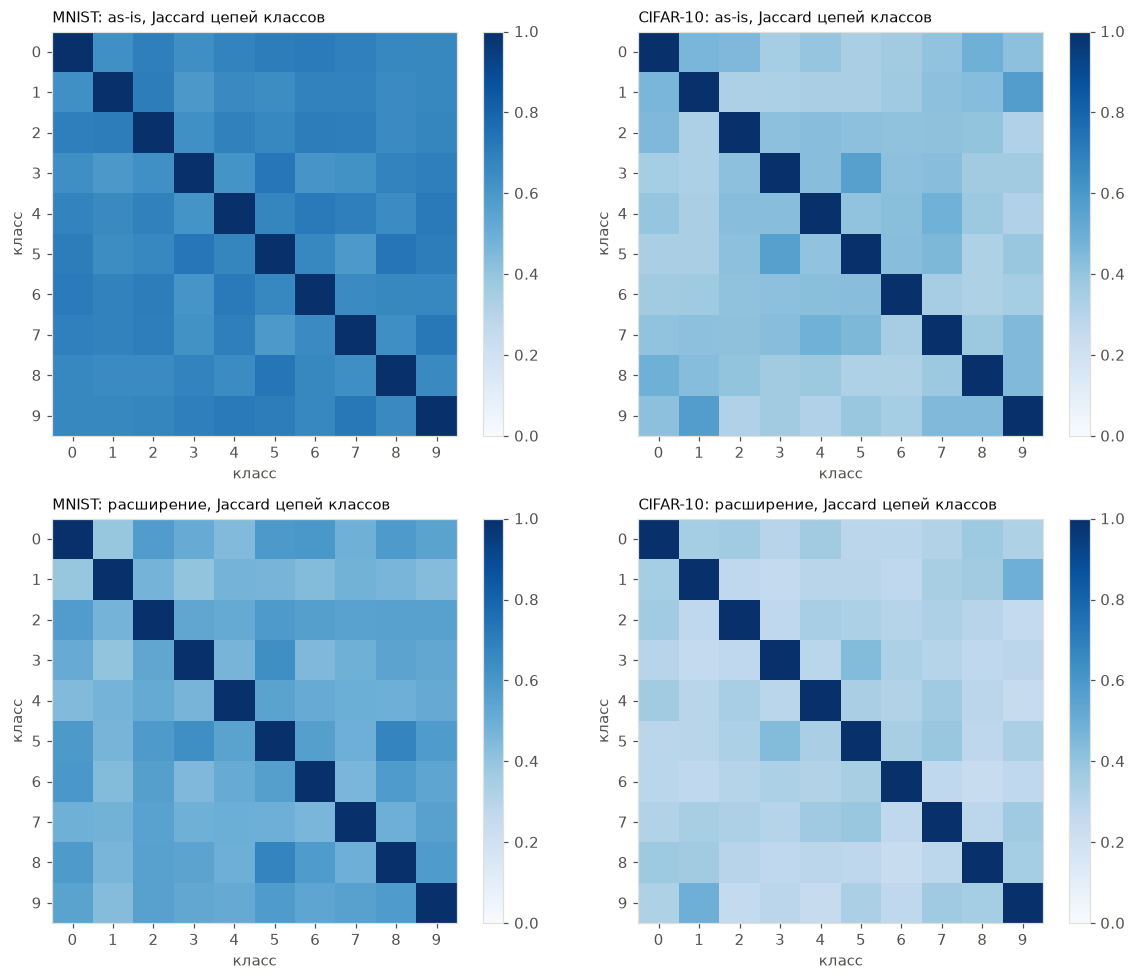

Средний Jaccard между цепями разных классов (1 - цепи одинаковы, 0 - не пересекаются):


,as-is,расширение
CIFAR-10,0.401,0.316
MNIST,0.668,0.522


In [8]:
# 6.1 Размеры и специфичность цепей классов (цепь = отобранные узлы трёх слоёв; подсеть содержит один логит)
s = sub[(sub.method == M_EXT) & (~sub.ft)].groupby(['dataset', 'cls'])[['n_conv1', 'n_conv2', 'n_fc1', 'w_share', 'mac_share']].mean()
s['asis_w_share'] = sub[(sub.method == M_ASIS_NAT) & (~sub.ft)].groupby(['dataset', 'cls']).w_share.mean()
s.index.names = ['датасет', 'класс']
s.columns = ['узлов conv1', 'узлов conv2', 'узлов fc1', 'доля весов (расширение)', 'доля MAC (расширение)', 'доля весов (as-is, естеств. размер)']
print('Цепь расширения по классам (среднее по 5 сетям): число узлов на слой, доля весов и MAC относительно исходной сети (выходной слой - одна строка fc2), доля весов цепи as-is:')
display(s.round(3))
def jaccard_matrix(sets_by_class):
    ids = {k: {(l, j) for l, v in sets_by_class[k].items() for j in v} for k in range(10)}
    return np.array([[len(ids[a] & ids[b]) / len(ids[a] | ids[b]) for b in range(10)] for a in range(10)])
fig, axes = plt.subplots(2, len(DATASETS), figsize=(5.4 * len(DATASETS), 9), squeeze=False)
off = {}
for j, ds in enumerate(DATASETS):
    for i, (key, ttl) in enumerate([('asis_sets', 'as-is'), ('ext_sets', 'расширение')]):
        M = np.mean([jaccard_matrix(RES[(ds, s_)][key]) for s_ in SEEDS], axis=0); ax = axes[i, j]
        im = ax.imshow(M, cmap='Blues', vmin=0, vmax=1); ax.set_xticks(range(10)); ax.set_yticks(range(10)); ax.set_title(f'{ds}: {ttl}, Jaccard цепей классов', loc='left', fontsize=10)
        ax.set_xlabel('класс'); ax.set_ylabel('класс'); plt.colorbar(im, ax=ax, fraction=0.046)
        off[(ds, ttl)] = (M.sum() - np.trace(M)) / 90
plt.tight_layout(); plt.show()
print('Средний Jaccard между цепями разных классов (1 - цепи одинаковы, 0 - не пересекаются):'); display(pd.Series(off).unstack().round(3))

### 6.2 Качество подсети одного класса

AUROC подсети с одним логитом против подсетей того же размера. Чёрная риска на графике - AUROC логита исходной сети для этого класса.

Без дообучения:


доля весов подсети          AUROC  \
датасет  метод                                                           
MNIST    расширение (синергия)            0.354 ± 0.026  0.843 ± 0.023   
         as-is (топ-ATE)                  0.354 ± 0.026  0.850 ± 0.018   
         магнитуда (пути)                 0.354 ± 0.026  0.954 ± 0.008   
         случайный (узлы)                 0.354 ± 0.026  0.856 ± 0.048   
         as-is (естественный размер)      0.499 ± 0.040  0.862 ± 0.022   
CIFAR-10 расширение (синергия)            0.166 ± 0.018  0.684 ± 0.036   
         as-is (топ-ATE)                  0.166 ± 0.018  0.648 ± 0.017   
         магнитуда (пути)                 0.166 ± 0.018  0.748 ± 0.039   
         случайный (узлы)                 0.166 ± 0.018  0.640 ± 0.027   
         as-is (естественный размер)      0.224 ± 0.021  0.667 ± 0.017   

                                                 AP  \
датасет  метод                                        
MNIST    расширение (синергия)        0.476 ± 0.054   
         as-is (топ-ATE)              0.473 ± 0.056   
         магнитуда (пути)             0.757 ± 0.030   
         случайный (узлы)             0.488 ± 0.095   
         as-is (естественный размер)  0.507 ± 0.069   
CIFAR-10 расширение (синергия)        0.226 ± 0.028   
         as-is (топ-ATE)              0.205 ± 0.015   
         магнитуда (пути)             0.287 ± 0.055   
         случайный (узлы)             0.177 ± 0.016   
         as-is (естественный размер)  0.227 ± 0.011   

                                     корр. с логитом исходной сети  \
датасет  метод                                                       
MNIST    расширение (синергия)                       0.637 ± 0.041   
         as-is (топ-ATE)                             0.643 ± 0.033   
         магнитуда (пути)                            0.863 ± 0.040   
         случайный (узлы)                            0.623 ± 0.081   
         as-is (естественный размер)                 0.684 ± 0.047   
CIFAR-10 расширение (синергия)                       0.351 ± 0.071   
         as-is (топ-ATE)                             0.273 ± 0.029   
         магнитуда (пути)                            0.516 ± 0.085   
         случайный (узлы)                            0.294 ± 0.058   
         as-is (естественный размер)                 0.313 ± 0.035   

                                     AUROC исходной сети  \
датасет  метод                                             
MNIST    расширение (синергия)             0.983 ± 0.003   
         as-is (топ-ATE)                   0.983 ± 0.003   
         магнитуда (пути)                  0.983 ± 0.003   
         случайный (узлы)                  0.983 ± 0.003   
         as-is (естественный размер)       0.983 ± 0.003   
CIFAR-10 расширение (синергия)             0.922 ± 0.002   
         as-is (топ-ATE)                   0.922 ± 0.002   
         магнитуда (пути)                  0.922 ± 0.002   
         случайный (узлы)                  0.922 ± 0.002   
         as-is (естественный размер)       0.922 ± 0.002   

                                     Δ AUROC: расширение минус метод (побед / поражений из пар класс x сеть)  
датасет  метод                                                                                                
MNIST    расширение (синергия)                                                        -                       
         as-is (топ-ATE)                                         -0.007 (17 / 18 из 50)                       
         магнитуда (пути)                                         -0.111 (2 / 48 из 50)                       
         случайный (узлы)                                        -0.013 (21 / 29 из 50)                       
         as-is (естественный размер)                             -0.019 (15 / 34 из 50)                       
CIFAR-10 расширение (синергия)                                                        -                       
         as-is (топ-ATE)             


После дообучения подсети (маска фиксирована структурно; случайная линия - 1 розыгрыш):


доля весов подсети          AUROC  \
датасет  метод                                                     
MNIST    расширение (синергия)      0.354 ± 0.026  0.988 ± 0.002   
         as-is (топ-ATE)            0.354 ± 0.026  0.987 ± 0.002   
         магнитуда (пути)           0.354 ± 0.026  0.996 ± 0.000   
         случайный (узлы)           0.354 ± 0.026  0.994 ± 0.002   
CIFAR-10 расширение (синергия)      0.166 ± 0.018  0.908 ± 0.003   
         as-is (топ-ATE)            0.166 ± 0.018  0.900 ± 0.004   
         магнитуда (пути)           0.166 ± 0.018  0.923 ± 0.004   
         случайный (узлы)           0.166 ± 0.018  0.913 ± 0.004   

                                           AP корр. с логитом исходной сети  \
датасет  метод                                                                
MNIST    расширение (синергия)  0.949 ± 0.008                 0.786 ± 0.029   
         as-is (топ-ATE)        0.943 ± 0.008                 0.788 ± 0.031   
         магнитуда (пути)       0.980 ± 0.003                 0.890 ± 0.010   
         случайный (узлы)       0.965 ± 0.010                 0.885 ± 0.013   
CIFAR-10 расширение (синергия)  0.632 ± 0.012                 0.720 ± 0.019   
         as-is (топ-ATE)        0.606 ± 0.018                 0.710 ± 0.036   
         магнитуда (пути)       0.655 ± 0.015                 0.829 ± 0.007   
         случайный (узлы)       0.615 ± 0.016                 0.825 ± 0.004   

                               AUROC исходной сети  \
датасет  метод                                       
MNIST    расширение (синергия)       0.983 ± 0.003   
         as-is (топ-ATE)             0.983 ± 0.003   
         магнитуда (пути)            0.983 ± 0.003   
         случайный (узлы)            0.983 ± 0.003   
CIFAR-10 расширение (синергия)       0.922 ± 0.002   
         as-is (топ-ATE)             0.922 ± 0.002   
         магнитуда (пути)            0.922 ± 0.002   
         случайный (узлы)            0.922 ± 0.002   

                               Δ AUROC: расширение минус метод (побед / поражений из пар класс x сеть)  
датасет  метод                                                                                          
MNIST    расширение (синергия)                                                  -                       
         as-is (топ-ATE)                                    +0.001 (26 / 9 из 50)                       
         магнитуда (пути)                                   -0.008 (0 / 50 из 50)                       
         случайный (узлы)                                   -0.006 (3 / 47 из 50)                       
CIFAR-10 расширение (синергия)                                                  -                       
         as-is (топ-ATE)                                   +0.009 (34 / 16 из 50)                       
         магнитуда (пути)                                   -0.015 (0 / 50 из 50)                       
         случайный (узлы)                                  -0.005 (18 / 32 из 50)

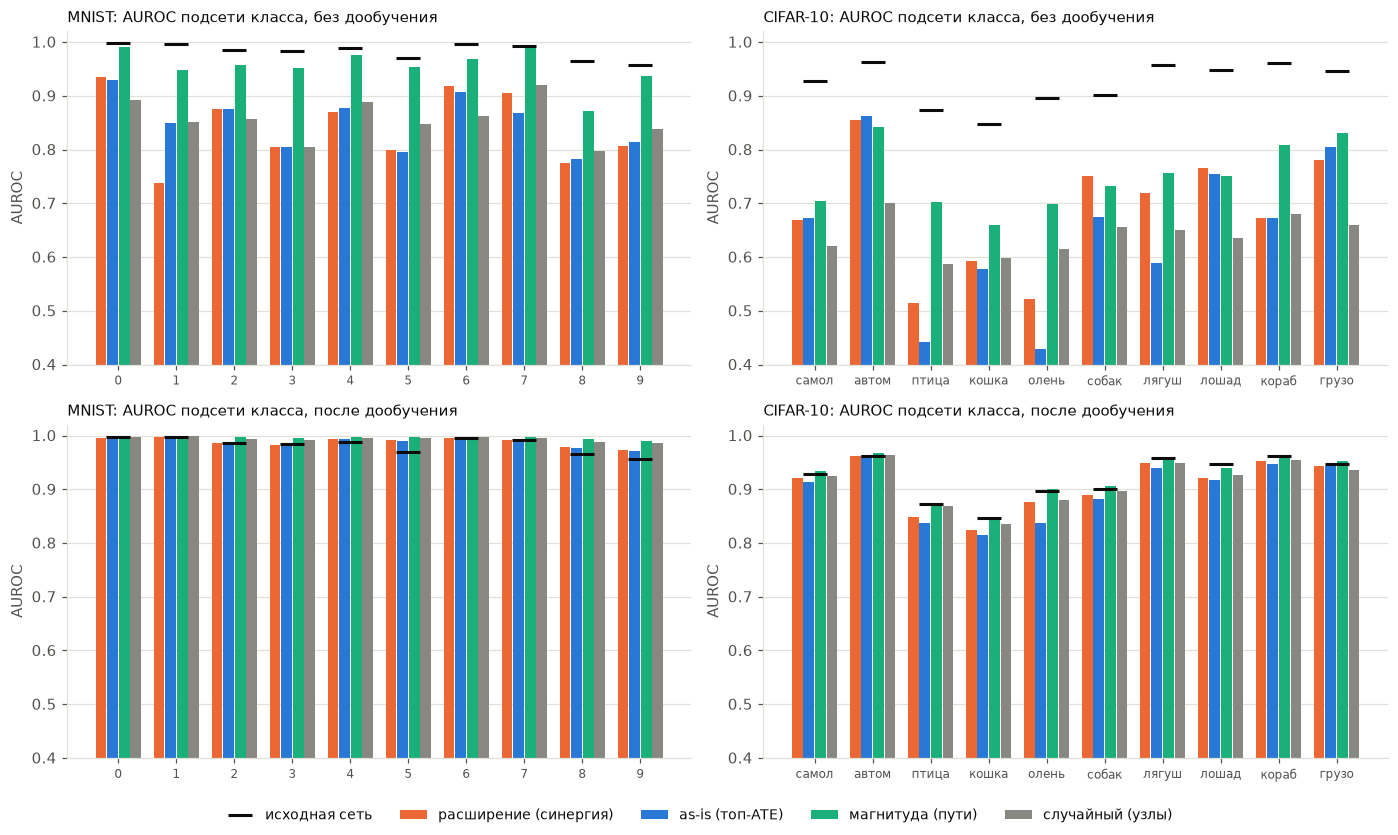

In [9]:
# 6.2 Качество подсети одного класса (один логит), без дообучения и после дообучения. AUROC "класс против остальных" не зависит от порога и масштаба логита.
def sub_table(ft):
    out = []
    for ds in DATASETS:
        d = sub[(sub.dataset == ds) & (sub.ft == ft)].groupby(['seed', 'method'])[['auroc', 'ap', 'corr_orig', 'w_share', 'mac_share']].mean().reset_index()
        o = sub[(sub.dataset == ds) & (sub.method == M_EXT) & (~sub.ft)].groupby('seed').orig_auroc.mean()
        for m in [M_EXT, M_ASIS, M_MAG, M_RND, M_ASIS_NAT]:
            x = d[d.method == m]
            if not len(x): continue
            p = paired(sub, 'auroc', ds, ft, m) if m != M_EXT else None
            out.append({'датасет': ds, 'метод': m, 'доля весов подсети': fmt(x.w_share.mean(), x.w_share.std(), 3), 'AUROC': fmt(x.auroc.mean(), x.auroc.std(), 3), 'AP': fmt(x.ap.mean(), x.ap.std(), 3),
                        'корр. с логитом исходной сети': fmt(x.corr_orig.mean(), x.corr_orig.std(), 3), 'AUROC исходной сети': fmt(o.mean(), o.std(), 3),
                        'Δ AUROC: расширение минус метод (побед / поражений из пар класс x сеть)': '-' if p is None else f'{p[0]:+.3f} ({p[1]} / {p[2]} из {p[3]})'})
    return pd.DataFrame(out).set_index(['датасет', 'метод'])
print('Без дообучения:'); display(sub_table(False))
print('\nПосле дообучения подсети (маска фиксирована структурно; случайная линия - 1 розыгрыш):'); display(sub_table(True))

fig, axes = plt.subplots(2, len(DATASETS), figsize=(6.4 * len(DATASETS), 7.6), squeeze=False)
for j, ds in enumerate(DATASETS):
    for i, ft in enumerate([False, True]):
        ax = axes[i, j]; d = sub[(sub.dataset == ds) & (sub.ft == ft)].groupby(['cls', 'method']).auroc.mean().unstack('method'); w = 0.2
        for m_i, m in enumerate(CTRL): ax.bar(np.arange(10) + (m_i - 1.5) * w, d[m], w * 0.92, color=COL[m], label=m, linewidth=0)
        o = sub[(sub.dataset == ds) & (sub.method == M_EXT) & (~sub.ft)].groupby('cls').orig_auroc.mean(); ax.plot(np.arange(10), o.values, ls='none', marker='_', ms=16, mew=2, color=INK, label='исходная сеть')
        ax.set_xticks(range(10)); ax.set_xticklabels([c[:5] for c in CLASS_NAMES[ds]], rotation=0, fontsize=8); ax.set_ylim(0.4, 1.02)
        style(ax, f'{ds}: AUROC подсети класса, {"после дообучения" if ft else "без дообучения"}', '', 'AUROC')
h, l = axes[0, 0].get_legend_handles_labels(); fig.legend(h, l, loc='lower center', ncol=5, frameon=False, fontsize=9); plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

### 6.3 Мета-модель (стекинг) и accuracy по классам

Главный итог для класс-специфичной задачи: точность 10-классовой классификации по логитам подсетей, в целом и по классам, против исходной сети и против контролей.

Без дообучения подсетей (as-is (естественный размер) - другой размер, справочно):


acc мета-модели macro-F1 мета-модели  \
датасет  метод                                                               
MNIST    исходная сеть (argmax)       0.9449 ± 0.0061                    -   
         исходная сеть + мета-модель  0.9504 ± 0.0049      0.9500 ± 0.0049   
         расширение (синергия)        0.9280 ± 0.0033      0.9273 ± 0.0032   
         as-is (топ-ATE)              0.9282 ± 0.0049      0.9274 ± 0.0049   
         магнитуда (пути)             0.9314 ± 0.0056      0.9307 ± 0.0055   
         случайный (узлы)             0.9134 ± 0.0114      0.9125 ± 0.0117   
         as-is (естественный размер)  0.9442 ± 0.0077      0.9436 ± 0.0079   
CIFAR-10 исходная сеть (argmax)       0.6693 ± 0.0061                    -   
         исходная сеть + мета-модель  0.6751 ± 0.0034      0.6733 ± 0.0034   
         расширение (синергия)        0.4269 ± 0.0305      0.4197 ± 0.0316   
         as-is (топ-ATE)              0.4542 ± 0.0287      0.4476 ± 0.0309   
         магнитуда (пути)             0.4265 ± 0.0407      0.4198 ± 0.0416   
         случайный (узлы)             0.3709 ± 0.0216      0.3623 ± 0.0225   
         as-is (естественный размер)  0.4895 ± 0.0218      0.4848 ± 0.0240   

                                     acc argmax логитов подсетей  \
датасет  метод                                                     
MNIST    исходная сеть (argmax)                                -   
         исходная сеть + мета-модель                           -   
         расширение (синергия)                   0.3002 ± 0.0703   
         as-is (топ-ATE)                         0.3291 ± 0.0644   
         магнитуда (пути)                        0.5995 ± 0.0590   
         случайный (узлы)                        0.2371 ± 0.0371   
         as-is (естественный размер)             0.7486 ± 0.1317   
CIFAR-10 исходная сеть (argmax)                                -   
         исходная сеть + мета-модель                           -   
         расширение (синергия)                   0.2451 ± 0.0581   
         as-is (топ-ATE)                         0.1831 ± 0.0427   
         магнитуда (пути)                        0.2392 ± 0.0346   
         случайный (узлы)                        0.1470 ± 0.0104   
         as-is (естественный размер)             0.1829 ± 0.0427   

                                     Δ acc: расширение минус метод (побед из сетей)  
датасет  метод                                                                       
MNIST    исходная сеть (argmax)                                                   -  
         исходная сеть + мета-модель                                              -  
         расширение (синергия)                                                    -  
         as-is (топ-ATE)                                           -0.0002 (2 из 5)  
         магнитуда (пути)                                          -0.0034 (2 из 5)  
         случайный (узлы)                                          +0.0146 (4 из 5)  
         as-is (естественный размер)                               -0.0162 (0 из 5)  
CIFAR-10 исходная сеть (argmax)                                                   -  
         исходная сеть + мета-модель                                              -  
         расширение (синергия)                                                    -  
         as-is (топ-ATE)                                           -0.0273 (1 из 5)  
         магнитуда (пути)                                          +0.0004 (3 из 5)  
         случайный (узлы)                                          +0.0560 (5 из 5)  
         as-is (естественный размер)                               -0.0626 (0 из 5)


После дообучения подсетей:


acc мета-модели macro-F1 мета-модели  \
датасет  метод                                                               
MNIST    исходная сеть (argmax)       0.9449 ± 0.0061                    -   
         исходная сеть + мета-модель  0.9504 ± 0.0049      0.9500 ± 0.0049   
         расширение (синергия)        0.9367 ± 0.0056      0.9364 ± 0.0057   
         as-is (топ-ATE)              0.9336 ± 0.0048      0.9331 ± 0.0051   
         магнитуда (пути)             0.9603 ± 0.0032      0.9601 ± 0.0032   
         случайный (узлы)             0.9513 ± 0.0049      0.9510 ± 0.0049   
CIFAR-10 исходная сеть (argmax)       0.6693 ± 0.0061                    -   
         исходная сеть + мета-модель  0.6751 ± 0.0034      0.6733 ± 0.0034   
         расширение (синергия)        0.6285 ± 0.0092      0.6275 ± 0.0101   
         as-is (топ-ATE)              0.6126 ± 0.0154      0.6111 ± 0.0160   
         магнитуда (пути)             0.6432 ± 0.0117      0.6409 ± 0.0120   
         случайный (узлы)             0.6222 ± 0.0127      0.6195 ± 0.0129   

                                     acc argmax логитов подсетей  \
датасет  метод                                                     
MNIST    исходная сеть (argmax)                                -   
         исходная сеть + мета-модель                           -   
         расширение (синергия)                   0.9233 ± 0.0065   
         as-is (топ-ATE)                         0.9182 ± 0.0079   
         магнитуда (пути)                        0.9505 ± 0.0100   
         случайный (узлы)                        0.9202 ± 0.0395   
CIFAR-10 исходная сеть (argmax)                                -   
         исходная сеть + мета-модель                           -   
         расширение (синергия)                   0.6185 ± 0.0120   
         as-is (топ-ATE)                         0.6009 ± 0.0121   
         магнитуда (пути)                        0.6345 ± 0.0117   
         случайный (узлы)                        0.6097 ± 0.0138   

                                     Δ acc: расширение минус метод (побед из сетей)  
датасет  метод                                                                       
MNIST    исходная сеть (argmax)                                                   -  
         исходная сеть + мета-модель                                              -  
         расширение (синергия)                                                    -  
         as-is (топ-ATE)                                           +0.0032 (4 из 5)  
         магнитуда (пути)                                          -0.0235 (0 из 5)  
         случайный (узлы)                                          -0.0146 (0 из 5)  
CIFAR-10 исходная сеть (argmax)                                                   -  
         исходная сеть + мета-модель                                              -  
         расширение (синергия)                                                    -  
         as-is (топ-ATE)                                           +0.0158 (5 из 5)  
         магнитуда (пути)                                          -0.0147 (0 из 5)  
         случайный (узлы)                                          +0.0063 (4 из 5)

Recall по классам после мета-модели, при равном числе узлов на слой (6.1). Ниже - средний recall по 5 сетям для исходной сети и каждого метода,
и отдельно - попарное сравнение с расширением: разница recall(расширение) - recall(метод) внутри 50 пар (класс x сеть), поделённая на выигранные,
проигранные и нейтральные пары - так видно не только знак и размер среднего эффекта, но и его устойчивость по классам и сетям.

=== MNIST: recall по классам после мета-модели, без дообучения (среднее по сетям) ===


...

,"Δ recall, среднее (расширение - метод)",расширение лучше,расширение хуже,без разницы / нет данных,пар всего
метод сравнения,,,,,
as-is (топ-ATE),-0.0273,17,32,1,50
магнитуда (пути),+0.0004,21,28,1,50
случайный (узлы),+0.0560,39,11,0,50


=== CIFAR-10: то же после дообучения подсетей ===


method,исходная сеть,расширение (синергия),as-is (топ-ATE),магнитуда (пути),случайный (узлы)
самолёт,0.723,0.666,0.643,0.681,0.647
автомобиль,0.766,0.740,0.743,0.758,0.737
птица,0.521,0.471,0.434,0.482,0.484
кошка,0.520,0.418,0.419,0.405,0.386
олень,0.618,0.541,0.481,0.569,0.528
собака,0.539,0.549,0.526,0.567,0.546
лягушка,0.747,0.737,0.737,0.762,0.748
лошадь,0.685,0.668,0.660,0.673,0.672
корабль,0.814,0.749,0.740,0.774,0.756
грузовик,0.760,0.746,0.743,0.760,0.719


--- CIFAR-10: попарное сравнение с расширением, после дообучения ---


,"Δ recall, среднее (расширение - метод)",расширение лучше,расширение хуже,без разницы / нет данных,пар всего
метод сравнения,,,,,
as-is (топ-ATE),+0.0158,33,17,0,50
магнитуда (пути),-0.0147,13,36,1,50
случайный (узлы),+0.0063,30,19,1,50


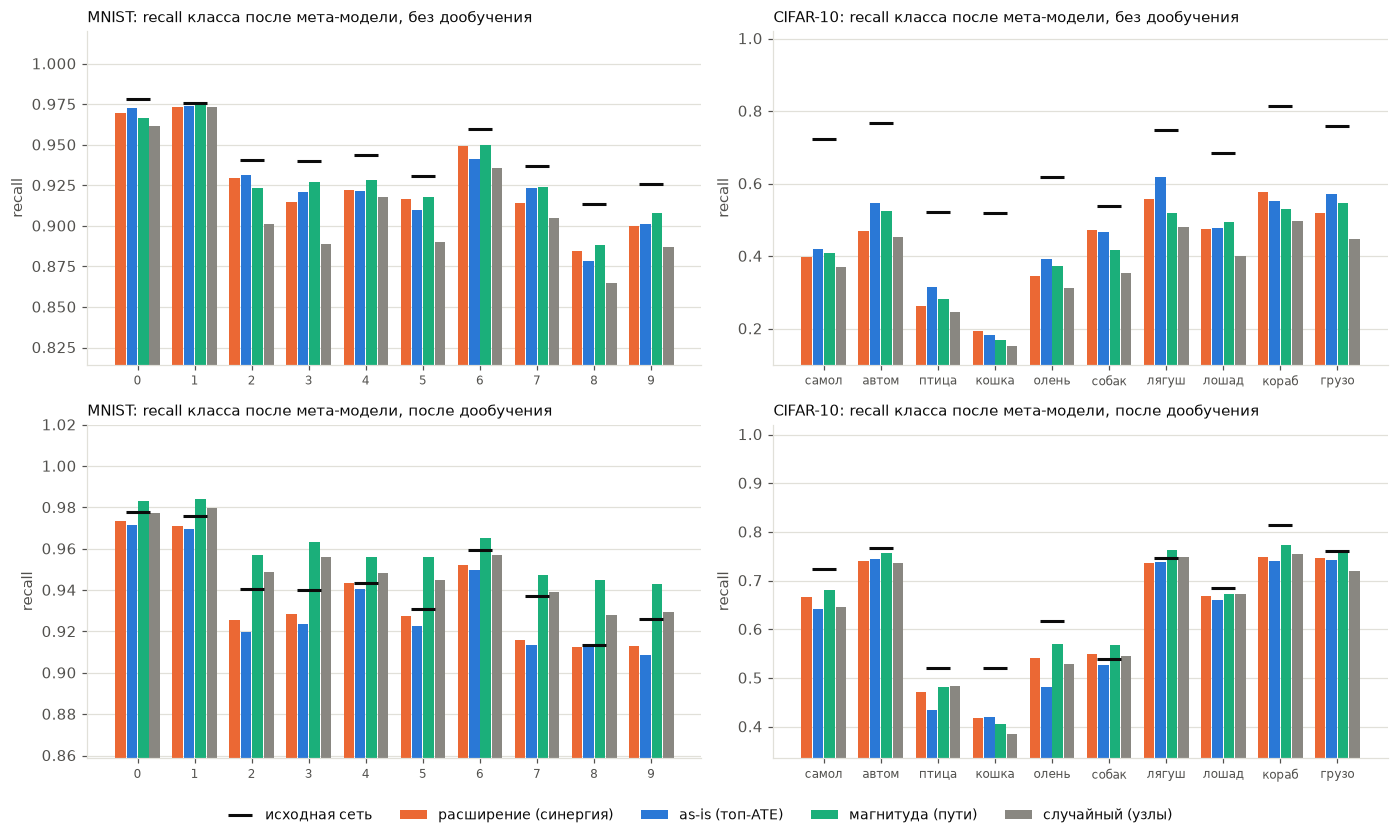

In [10]:
# 6.3 Мета-модель (стекинг): 10 подсетей -> 10 логитов -> многоклассовая логистическая регрессия, обученная на мета-выборке (не пересекается ни с обучением сети, ни с отбором путей, ни с тестом)
def stack_table(ft):
    out = []
    for ds in DATASETS:
        d = stack[(stack.dataset == ds) & (stack.ft == ft)].groupby(['seed', 'method'])[['acc', 'macro_f1', 'raw_acc']].mean().reset_index()
        r = ref[ref.dataset == ds]
        out.append({'датасет': ds, 'метод': 'исходная сеть (argmax)', 'acc мета-модели': fmt(r.orig_acc.mean(), r.orig_acc.std()), 'macro-F1 мета-модели': '-', 'acc argmax логитов подсетей': '-', 'Δ acc: расширение минус метод (побед из сетей)': '-'})
        out.append({'датасет': ds, 'метод': 'исходная сеть + мета-модель', 'acc мета-модели': fmt(r.orig_stack_acc.mean(), r.orig_stack_acc.std()), 'macro-F1 мета-модели': fmt(r.orig_stack_macro_f1.mean(), r.orig_stack_macro_f1.std()),
                    'acc argmax логитов подсетей': '-', 'Δ acc: расширение минус метод (побед из сетей)': '-'})
        e = d[d.method == M_EXT].set_index('seed')
        for m in [M_EXT, M_ASIS, M_MAG, M_RND, M_ASIS_NAT]:
            x = d[d.method == m]
            if not len(x): continue
            dl = (e.acc - x.set_index('seed').acc) if m != M_EXT else None
            out.append({'датасет': ds, 'метод': m, 'acc мета-модели': fmt(x.acc.mean(), x.acc.std()), 'macro-F1 мета-модели': fmt(x.macro_f1.mean(), x.macro_f1.std()), 'acc argmax логитов подсетей': fmt(x.raw_acc.mean(), x.raw_acc.std()),
                        'Δ acc: расширение минус метод (побед из сетей)': '-' if dl is None else f'{dl.mean():+.4f} ({int((dl > 0).sum())} из {len(dl)})'})
    return pd.DataFrame(out).set_index(['датасет', 'метод'])
print('Без дообучения подсетей (as-is (естественный размер) - другой размер, справочно):'); display(stack_table(False))
print('\nПосле дообучения подсетей:'); display(stack_table(True))

def cls_table(ds, ft):
    '''Recall по классам после мета-модели: строки - классы, столбцы - исходная сеть и методы отбора узлов (равное число узлов на слой, см. 6.1).'''
    d = cls[(cls.dataset == ds) & (cls.ft == ft)].groupby(['seed', 'cls', 'method'])[['recall', 'f1']].mean().reset_index()
    t = d.groupby(['cls', 'method']).recall.mean().unstack('method')[CTRL]; t.insert(0, 'исходная сеть', cls[(cls.dataset == ds) & (cls.method == M_EXT) & (~cls.ft)].groupby('cls').orig_recall.mean()); t = t.round(3)
    t.index = [CLASS_NAMES[ds][i] if isinstance(i, (int, np.integer)) else i for i in t.index]; return t

def cls_delta_table(ds, ft):
    '''Попарное сравнение расширения с каждым контролем по recall класса. Пара = (класс, сеть): 10 классов x 5 сетей = 50 пар.
       Дельта = recall(расширение) - recall(метод) внутри одной и той же пары; отдельно считаем число пар, где расширение лучше,
       где хуже, и где разницы нет или пара недоступна (три числа в сумме дают "пар всего").'''
    rows = []
    for m in [M_ASIS, M_MAG, M_RND]:
        mean_d, wins, losses, n = paired(cls, 'recall', ds, ft, m)
        rows.append({'метод сравнения': m, 'Δ recall, среднее (расширение - метод)': f'{mean_d:+.4f}',
                      'расширение лучше': wins, 'расширение хуже': losses, 'без разницы / нет данных': n - wins - losses, 'пар всего': n})
    return pd.DataFrame(rows).set_index('метод сравнения')

print('Recall по классам после мета-модели, при равном числе узлов на слой (6.1). Ниже - средний recall по 5 сетям для исходной сети и каждого метода,')
print('и отдельно - попарное сравнение с расширением: разница recall(расширение) - recall(метод) внутри 50 пар (класс x сеть), поделённая на выигранные,')
print('проигранные и нейтральные пары - так видно не только знак и размер среднего эффекта, но и его устойчивость по классам и сетям.')
for ds in DATASETS:
    print(f'\n=== {ds}: recall по классам после мета-модели, без дообучения (среднее по сетям) ==='); display(cls_table(ds, False))
    print(f'--- {ds}: попарное сравнение с расширением, без дообучения ---'); display(cls_delta_table(ds, False))
    print(f'=== {ds}: то же после дообучения подсетей ==='); display(cls_table(ds, True))
    print(f'--- {ds}: попарное сравнение с расширением, после дообучения ---'); display(cls_delta_table(ds, True))

fig, axes = plt.subplots(2, len(DATASETS), figsize=(6.4 * len(DATASETS), 7.6), squeeze=False)
for j, ds in enumerate(DATASETS):
    for i, ft in enumerate([False, True]):
        ax = axes[i, j]; d = cls[(cls.dataset == ds) & (cls.ft == ft)].groupby(['cls', 'method']).recall.mean().unstack('method'); w = 0.2
        for m_i, m in enumerate(CTRL): ax.bar(np.arange(10) + (m_i - 1.5) * w, d[m], w * 0.92, color=COL[m], label=m, linewidth=0)
        o = cls[(cls.dataset == ds) & (cls.method == M_EXT) & (~cls.ft)].groupby('cls').orig_recall.mean(); ax.plot(np.arange(10), o.values, ls='none', marker='_', ms=16, mew=2, color=INK, label='исходная сеть')
        ax.set_xticks(range(10)); ax.set_xticklabels([c[:5] for c in CLASS_NAMES[ds]], fontsize=8); ax.set_ylim(max(0, d.values.min() - 0.05), 1.02)
        style(ax, f'{ds}: recall класса после мета-модели, {"после дообучения" if ft else "без дообучения"}', '', 'recall')
h, l = axes[0, 0].get_legend_handles_labels(); fig.legend(h, l, loc='lower center', ncol=5, frameon=False, fontsize=9); plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

### 6.4 Необходимость (протокол Fig. 10 статьи)

Если цепь действительно специфична для класса, маскирование её топ-узлов сильно роняет recall этого класса и слабо - остальные.

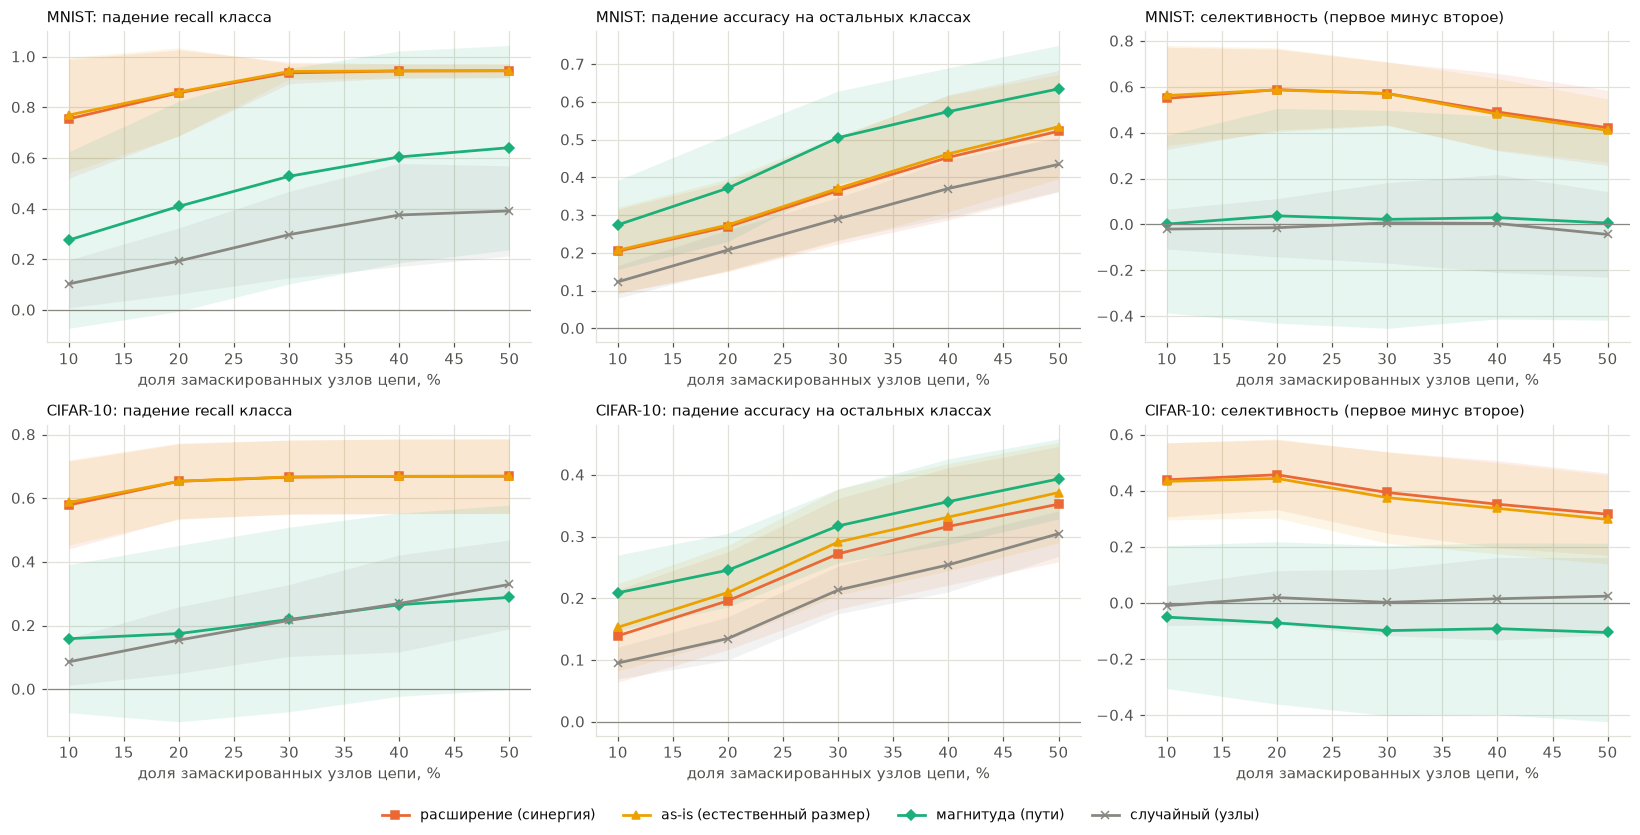

Селективность по долям (среднее по классам и сетям):


portion                                 0.1    0.2    0.3    0.4    0.5
dataset  method                                                        
CIFAR-10 расширение (синергия)        0.439  0.457  0.394  0.352  0.317
         as-is (естественный размер)  0.434  0.444  0.376  0.337  0.298
         магнитуда (пути)            -0.050 -0.071 -0.098 -0.091 -0.105
         случайный (узлы)            -0.009  0.019  0.002  0.015  0.024
MNIST    расширение (синергия)        0.550  0.588  0.571  0.491  0.422
         as-is (естественный размер)  0.562  0.587  0.571  0.481  0.410
         магнитуда (пути)             0.002  0.038  0.022  0.030  0.006
         случайный (узлы)            -0.020 -0.014  0.007  0.004 -0.044

In [11]:
# 6.4 Необходимость (протокол Fig. 10 статьи): маскируем долю узлов цепи класса (топ по вкладу в логит) в полной сети. Хорошая цепь: recall_k падает сильно, точность на остальных классах - слабо.
n = nec.groupby(['dataset', 'seed', 'cls', 'method', 'portion'])[['drop_k', 'drop_other']].mean().reset_index(); n['selectivity'] = n.drop_k - n.drop_other
NM = [M_EXT, M_ASIS_NAT, M_MAG, M_RND]
fig, axes = plt.subplots(len(DATASETS), 3, figsize=(15, 3.8 * len(DATASETS)), squeeze=False)
for j, ds in enumerate(DATASETS):
    for i, (col, ttl) in enumerate([('drop_k', 'падение recall класса'), ('drop_other', 'падение accuracy на остальных классах'), ('selectivity', 'селективность (первое минус второе)')]):
        ax = axes[j, i]
        for m in NM:
            g = n[(n.dataset == ds) & (n.method == m)].groupby('portion')[col].agg(['mean', 'std']); ax.plot(g.index * 100, g['mean'], color=COL[m], marker=MRK[m], ms=5, lw=1.8, label=m)
            ax.fill_between(g.index * 100, g['mean'] - g['std'], g['mean'] + g['std'], color=COL[m], alpha=0.10, linewidth=0)
        ax.axhline(0, color=MUT, lw=0.8); style(ax, f'{ds}: {ttl}', 'доля замаскированных узлов цепи, %', '', grid='both')
h, l = axes[0, 0].get_legend_handles_labels(); fig.legend(h, l, loc='lower center', ncol=4, frameon=False, fontsize=9); plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()
sel = n.groupby(['dataset', 'method', 'portion']).selectivity.mean().unstack('portion').reindex(NM, level=1); print('Селективность по долям (среднее по классам и сетям):'); display(sel.round(3))

### 6.5 В чём выигрыш относительно исходной сети

Стоимость подсетей: параметры, MAC и измеренное время (компактные плотные сети, 1 поток). Качество и стоимость сведены вместе.

Стоимость относительно исходной сети (=1). "Одна подсеть" - ответ на вопрос "это класс k?"; "10 подсетей подряд" - полная 10-классовая классификация через стекинг; "объединение узлов" - те же узлы, общие узлы считаются один раз:


параметры / исходная  \
dataset  what                                                                       
CIFAR-10 10 подсетей подряд: as-is (топ-ATE)                                1.653   
         10 подсетей подряд: магнитуда (пути)                               1.653   
         10 подсетей подряд: расширение (синергия)                          1.653   
         исходная сеть                                                      1.000   
         объединение узлов (общие узлы считаются один ра...                 0.672   
         объединение узлов (общие узлы считаются один ра...                 0.599   
         объединение узлов (общие узлы считаются один ра...                 0.694   
         одна подсеть: as-is (топ-ATE)                                      0.165   
         одна подсеть: магнитуда (пути)                                     0.165   
         одна подсеть: расширение (синергия)                                0.165   
MNIST    10 подсетей подряд: as-is (топ-ATE)                                3.410   
         10 подсетей подряд: магнитуда (пути)                               3.410   
         10 подсетей подряд: расширение (синергия)                          3.410   
         исходная сеть                                                      1.000   
         объединение узлов (общие узлы считаются один ра...                 0.745   
         объединение узлов (общие узлы считаются один ра...                 0.886   
         объединение узлов (общие узлы считаются один ра...                 0.745   
         одна подсеть: as-is (топ-ATE)                                      0.341   
         одна подсеть: магнитуда (пути)                                     0.341   
         одна подсеть: расширение (синергия)                                0.341   

                                                             MAC / исходная  \
dataset  what                                                                 
CIFAR-10 10 подсетей подряд: as-is (топ-ATE)                          2.767   
         10 подсетей подряд: магнитуда (пути)                         2.767   
         10 подсетей подряд: расширение (синергия)                    2.767   
         исходная сеть                                                1.000   
         объединение узлов (общие узлы считаются один ра...           0.828   
         объединение узлов (общие узлы считаются один ра...           0.490   
         объединение узлов (общие узлы считаются один ра...           0.963   
         одна подсеть: as-is (топ-ATE)                                0.277   
         одна подсеть: магнитуда (пути)                               0.277   
         одна подсеть: расширение (синергия)                          0.277   
MNIST    10 подсетей подряд: as-is (топ-ATE)                          5.545   
         10 подсетей подряд: магнитуда (пути)                         5.545   
         10 подсетей подряд: расширение (синергия)                    5.545   
         исходная сеть                                                1.000   
         объединение узлов (общие узлы считаются один ра...           0.972   
         объединение узлов (общие узлы считаются один ра...           0.912   
         объединение узлов (общие узлы считаются один ра...           0.972   
         одна подсеть: as-is (топ-ATE)                                0.555   
         одна подсеть: магнитуда (пути)                               0.555   
         одна подсеть: расширение (синергия)                          0.555   

                                                             время, пакет 1 / исходная  \
dataset  what                                                                            
CIFAR-10 10 подсетей подряд: as-is (топ-ATE)                                     6.348   
         10 подсетей подряд: магнитуда (пути)                                    6.500   
         10 подсетей подряд: расширение (синергия)                               6.224   
 


Абсолютные значения (среднее по 5 сетям; время - 1 поток, медиана, мс):


params  \
dataset  what                                                            
CIFAR-10 10 подсетей подряд: as-is (топ-ATE)                 109021.20   
         10 подсетей подряд: магнитуда (пути)                109021.20   
         10 подсетей подряд: расширение (синергия)           109021.20   
         исходная сеть                                        65962.00   
         объединение узлов (общие узлы считаются один ра...   44346.40   
         объединение узлов (общие узлы считаются один ра...   39541.80   
         объединение узлов (общие узлы считаются один ра...   45793.40   
         одна подсеть: as-is (топ-ATE)                        10902.12   
         одна подсеть: магнитуда (пути)                       10902.12   
         одна подсеть: расширение (синергия)                  10902.12   
MNIST    10 подсетей подряд: as-is (топ-ATE)                  19710.40   
         10 подсетей подряд: магнитуда (пути)                 19710.40   
         10 подсетей подряд: расширение (синергия)            19710.40   
         исходная сеть                                         5780.00   
         объединение узлов (общие узлы считаются один ра...    4308.00   
         объединение узлов (общие узлы считаются один ра...    5123.20   
         объединение узлов (общие узлы считаются один ра...    4308.00   
         одна подсеть: as-is (топ-ATE)                         1971.04   
         одна подсеть: магнитуда (пути)                        1971.04   
         одна подсеть: расширение (синергия)                   1971.04   

                                                                   macs  \
dataset  what                                                             
CIFAR-10 10 подсетей подряд: as-is (топ-ATE)                 6287367.80   
         10 подсетей подряд: магнитуда (пути)                6287367.80   
         10 подсетей подряд: расширение (синергия)           6287367.80   
         исходная сеть                                       2272640.00   
         объединение узлов (общие узлы считаются один ра...  1881915.00   
         объединение узлов (общие узлы считаются один ра...  1112606.00   
         объединение узлов (общие узлы считаются один ра...  2189135.00   
         одна подсеть: as-is (топ-ATE)                        628736.78   
         одна подсеть: магнитуда (пути)                       628736.78   
         одна подсеть: расширение (синергия)                  628736.78   
MNIST    10 подсетей подряд: as-is (топ-ATE)                 1034031.80   
         10 подсетей подряд: магнитуда (пути)                1034031.80   
         10 подсетей подряд: расширение (синергия)           1034031.80   
         исходная сеть                                        186480.00   
         объединение узлов (общие узлы считаются один ра...   181236.00   
         объединение узлов (общие узлы считаются один ра...   169996.00   
         объединение узлов (общие узлы считаются один ра...   181236.00   
         одна подсеть: as-is (топ-ATE)                        103403.18   
         одна подсеть: магнитуда (пути)                       103403.18   
         одна подсеть: расширение (синергия)                  103403.18   

                                                             ms_batch1  \
dataset  what                                                            
CIFAR-10 10 подсетей подряд: as-is (топ-ATE)                     5.055   
         10 подсетей подряд: магнитуда (пути)                    5.176   
         10 подсетей подряд: расширение (синергия)               4.956   
         исходная сеть                                           0.796   
         объединение узлов (общие узлы считаются один ра...      0.654   
         объединение узлов (общие узлы считаются один ра...      0.541   
         объединение узлов (общие узлы считаются один ра...      0.654   
         одна подсеть: as-is (топ-ATE)                           0.491   
         одна подсеть: магнитуда (пути)     


Качество и стоимость вместе (случайная подсеть того же размера, что у расширения):


acc исходной сети  \
датасет  метод                                      
MNIST    расширение (синергия)             0.9449   
         as-is (топ-ATE)                   0.9449   
         магнитуда (пути)                  0.9449   
         случайный (узлы)                  0.9449   
CIFAR-10 расширение (синергия)             0.6693   
         as-is (топ-ATE)                   0.6693   
         магнитуда (пути)                  0.6693   
         случайный (узлы)                  0.6693   

                                acc стекинга без дообучения  \
датасет  метод                                                
MNIST    расширение (синергия)                       0.9280   
         as-is (топ-ATE)                             0.9282   
         магнитуда (пути)                            0.9314   
         случайный (узлы)                            0.9134   
CIFAR-10 расширение (синергия)                       0.4269   
         as-is (топ-ATE)                             0.4542   
         магнитуда (пути)                            0.4265   
         случайный (узлы)                            0.3709   

                                acc стекинга с дообучением  \
датасет  метод                                               
MNIST    расширение (синергия)                      0.9367   
         as-is (топ-ATE)                            0.9336   
         магнитуда (пути)                           0.9603   
         случайный (узлы)                           0.9513   
CIFAR-10 расширение (синергия)                      0.6285   
         as-is (топ-ATE)                            0.6126   
         магнитуда (пути)                           0.6432   
         случайный (узлы)                           0.6222   

                                MAC одной подсети / исходная  \
датасет  метод                                                 
MNIST    расширение (синергия)                        0.5545   
         as-is (топ-ATE)                              0.5545   
         магнитуда (пути)                             0.5545   
         случайный (узлы)                             0.5545   
CIFAR-10 расширение (синергия)                        0.2767   
         as-is (топ-ATE)                              0.2767   
         магнитуда (пути)                             0.2767   
         случайный (узлы)                             0.2767   

                                MAC 10 подсетей / исходная  
датасет  метод                                              
MNIST    расширение (синергия)                      5.5450  
         as-is (топ-ATE)                            5.5450  
         магнитуда (пути)                           5.5450  
         случайный (узлы)                              NaN  
CIFAR-10 расширение (синергия)                      2.7665  
         as-is (топ-ATE)                            2.7665  
         магнитуда (пути)                           2.7665  
         случайный (узлы)                              NaN

C:\Users\User\AppData\Local\Temp\ipykernel_5900\2332820769.py:26: UserWarning: You passed an edgecolor/edgecolors ('#0b0b0b') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, d[(m, True)], s=70, marker=MRK[m], color=COL[m], edgecolor=INK, zorder=4, label=m); ax.scatter(x, d[(m, False)], s=50, marker=MRK[m], facecolor='white', edgecolor=COL[m], zorder=4)
C:\Users\User\AppData\Local\Temp\ipykernel_5900\2332820769.py:26: UserWarning: You passed an edgecolor/edgecolors ('#898781') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, d[(m, True)], s=70, marker=MRK[m], color=COL[m], edgecolor=INK, zorder=4, label=m); ax.scatter(x, d[(m, False)], s=50, marker=MRK[m], facecolor='white', edgecolor=COL[m], zorder=4)
C:\Users\User\AppData\Local\Temp\ipykernel_5900\2332820769.py:26: UserWarning: You

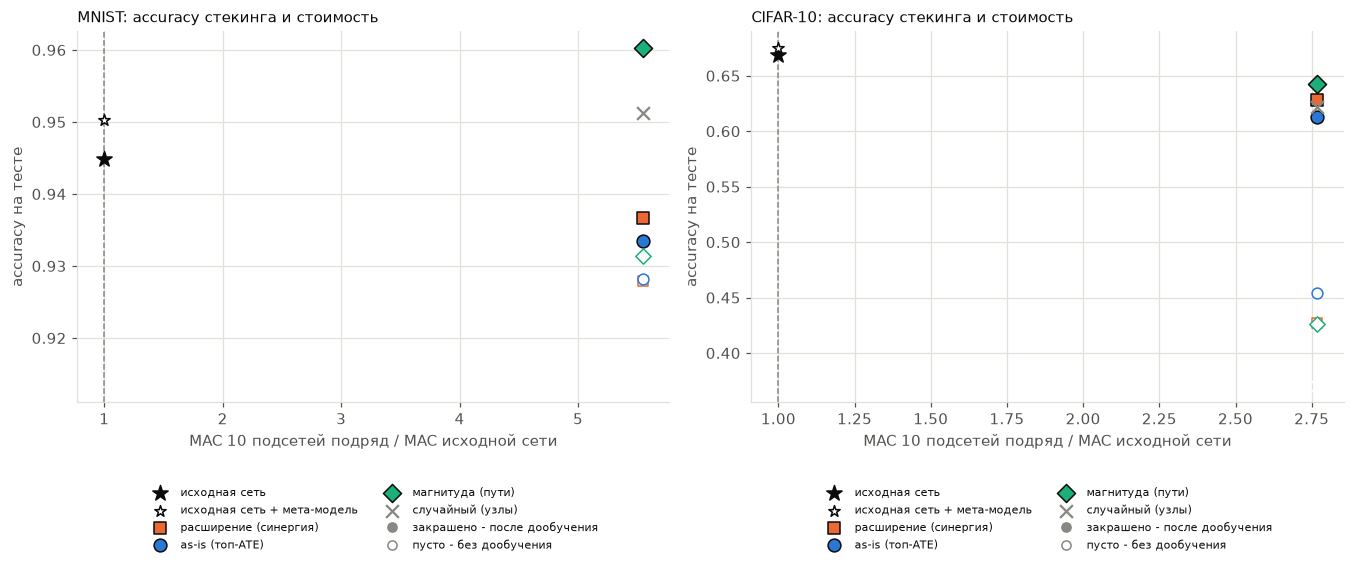

In [12]:
# 6.5 В чём выигрыш относительно исходной сети: размер, MAC и измеренная задержка. Качество берётся из 6.3.
lt = latency.groupby(['dataset', 'what'])[['params', 'macs', 'ms_batch1', 'ms_batch256']].mean()
full = lt.xs('исходная сеть', level=1)[['params', 'macs', 'ms_batch1', 'ms_batch256']]
rel = lt.copy()
for ds in DATASETS:
    for c in lt.columns: rel.loc[ds, c] = lt.loc[ds, c].values / float(full.loc[ds, c])
rel.columns = ['параметры / исходная', 'MAC / исходная', 'время, пакет 1 / исходная', 'время, пакет 256 / исходная']
print('Стоимость относительно исходной сети (=1). "Одна подсеть" - ответ на вопрос "это класс k?"; "10 подсетей подряд" - полная 10-классовая классификация через стекинг; "объединение узлов" - те же узлы, общие узлы считаются один раз:')
display(rel.round(3)); print('\nАбсолютные значения (среднее по 5 сетям; время - 1 поток, медиана, мс):'); display(lt.round(3))

rows_ = []
for ds in DATASETS:
    r = ref[ref.dataset == ds]; d = stack[stack.dataset == ds].groupby(['method', 'ft']).acc.mean()
    for m in [M_EXT, M_ASIS, M_MAG, M_RND]:
        macs_sum = rel.loc[(ds, f'10 подсетей подряд: {m}'), 'MAC / исходная'] if m != M_RND else np.nan
        rows_.append({'датасет': ds, 'метод': m, 'acc исходной сети': r.orig_acc.mean(), 'acc стекинга без дообучения': d[(m, False)], 'acc стекинга с дообучением': d[(m, True)],
                      'MAC одной подсети / исходная': rel.loc[(ds, f'одна подсеть: {m}'), 'MAC / исходная'] if m != M_RND else rel.loc[(ds, f'одна подсеть: {M_EXT}'), 'MAC / исходная'], 'MAC 10 подсетей / исходная': macs_sum})
print('\nКачество и стоимость вместе (случайная подсеть того же размера, что у расширения):'); display(pd.DataFrame(rows_).set_index(['датасет', 'метод']).round(4))

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.2 * len(DATASETS), 5.4), squeeze=False)
for ax, ds in zip(axes[0], DATASETS):
    d = stack[stack.dataset == ds].groupby(['method', 'ft']).acc.mean(); r = ref[ref.dataset == ds]
    ax.scatter(1.0, r.orig_acc.mean(), s=110, color=INK, marker='*', zorder=5, label='исходная сеть'); ax.scatter(1.0, r.orig_stack_acc.mean(), s=60, facecolor='white', edgecolor=INK, marker='*', zorder=5, label='исходная сеть + мета-модель')
    for m in [M_EXT, M_ASIS, M_MAG, M_RND]:
        x = rel.loc[(ds, f'10 подсетей подряд: {M_EXT if m == M_RND else m}'), 'MAC / исходная']      # у случайной подсети те же числа узлов, что у расширения
        ax.scatter(x, d[(m, True)], s=70, marker=MRK[m], color=COL[m], edgecolor=INK, zorder=4, label=m); ax.scatter(x, d[(m, False)], s=50, marker=MRK[m], facecolor='white', edgecolor=COL[m], zorder=4)
    ax.axvline(1.0, color=MUT, ls='--', lw=1); style(ax, f'{ds}: accuracy стекинга и стоимость', 'MAC 10 подсетей подряд / MAC исходной сети', 'accuracy на тесте', grid='both')
    h, l = ax.get_legend_handles_labels(); h += [plt.Line2D([], [], marker='o', ls='', color=MUT, ms=6), plt.Line2D([], [], marker='o', ls='', mfc='white', mec=MUT, ms=6)]; l += ['закрашено - после дообучения', 'пусто - без дообучения']
    ax.legend(h, l, frameon=False, fontsize=7.5, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout(); plt.show()

## 7. Интерпретация результатов и оценка идеи синергии

Все числа - из таблиц раздела 6 (среднее по 5 сетям; пары «класс x сеть» - 50 на датасет). Границы применимости: две малые сети, один протокол дообучения (3 эпохи, сбалансированная бинарная потеря), мета-модель - логистическая регрессия; результаты первой итерации.

**Итог.** Цепи класса, найденные as-is и расширением, действительно класс-специфичны по необходимости, но как основа для подсетей они не лучше подсетей того же размера, выбранных по магнитуде путей, а после дообучения не лучше случайных. Правило расширения меняет цепи класса заметно (они меньше и различаются сильнее), однако при равном размере даёт разницу с as-is до 3.7 п.п. по AUROC подсети и до 2.7 п.п. по стекингу; знак зависит от датасета и от дообучения. Стекинг десяти подсетей не даёт выигрыша по вычислениям относительно исходной сети.

**1. Размер и специфичность цепей (6.1).** Цепь расширения на класс: 16.6% весов и 27.7% MAC исходной сети у CIFAR-10 (в среднем 6.1 узла `conv1`, 17.5 `conv2`, 17.8 `fc1`), 35.4% и 55.5% у MNIST; цепь as-is на естественном размере больше (22.4% и 49.9% весов). То есть «маленькими» цепи можно назвать только на CIFAR-10. Цепи разных классов у расширения различаются сильнее, чем у as-is: средний Jaccard между классами 0.316 против 0.401 (CIFAR-10) и 0.522 против 0.668 (MNIST).

**2. Необходимость подтверждается для as-is и расширения одинаково (6.4).** Маскирование лишь 10% узлов цепи класса роняет recall этого класса на 0.579 (расширение) и 0.587 (as-is) на CIFAR-10 при побочном ущербе 0.139 и 0.153; такое же число случайных узлов роняет recall на 0.086 при побочном ущербе 0.095, узлы по магнитуде путей - на 0.159 при 0.209. Селективность (падение recall своего класса минус падение точности остальных) на 10-20% узлов: расширение 0.439-0.457, as-is 0.434-0.444, магнитуда от −0.05 до −0.07, случайные узлы от −0.01 до 0.02; на MNIST 0.550-0.588, 0.562-0.587, 0.00-0.04 и −0.02-−0.01. Это результат в пользу метода статьи (пути, выбранные по эффекту, специфичны для класса); разница расширения с as-is не превышает 0.019 и лежит внутри разброса.

**3. Подсеть одного класса без дообучения (6.2).** AUROC логита (исходная сеть 0.922 на CIFAR-10, 0.983 на MNIST): CIFAR-10 - расширение 0.684, as-is (топ-ATE) 0.648, случайная 0.640, магнитуда путей 0.748; MNIST - 0.843, 0.850, 0.856, 0.954. Расширение лучше as-is на CIFAR-10 на +0.037 (в 31 паре из 50) и не отличается на MNIST (−0.007, 17 из 50); магнитуда лучше расширения на MNIST в 48 парах из 50, на CIFAR-10 в 36. Стекинг без дообучения (доля правильных ответов, исходная сеть 0.669 и 0.945): CIFAR-10 - расширение 0.427, as-is 0.454 (расширение хуже на 0.027, побед 1/5), магнитуда 0.427, случайные 0.371 (расширение лучше на 0.056, побед 5/5); MNIST - 0.928, 0.928, 0.931, 0.913. То есть по вырезкам без обучения расширение не отличимо от as-is и магнитуды, а от случайных отличается.

**4. Дообучение стирает различия, кроме преимущества магнитуды (6.2-6.3).** После дообучения AUROC 0.900-0.923 (CIFAR-10) и 0.987-0.996 (MNIST). Стекинг: CIFAR-10 - расширение 0.6285, as-is 0.6126 (расширение лучше на +0.016, побед 5/5), магнитуда 0.6432 (расширение хуже на 0.015, побед 0/5), случайные 0.6222 (+0.006, побед 4/5); MNIST - расширение 0.9367, as-is 0.9336 (+0.003, побед 4/5), магнитуда 0.9603 (0/5), случайные 0.9513 (−0.015, 0/5). Исходная сеть: 0.6693 (0.6751 с той же мета-моделью) и 0.9449 (0.9504). На MNIST дообученные магнитудные и случайные подсети (0.9603 и 0.9513) превосходят исходную сеть с мета-моделью; так как случайный набор узлов даёт тот же эффект, он связан с дополнительным обучением, а не с отбором. По классам различия расширения с as-is малы и непостоянны (среднее по классам после дообучения +0.016 на CIFAR-10, побед 33 из 50 пар; без дообучения −0.027, побед 17, поражений 32).

**5. В чём выигрыш относительно исходной сети (6.5).** *Один класс* («это класс $k$?»): подсеть расширения - 16.5% параметров, 27.7% MAC и 50% времени пакета 256 (64% при пакете 1) исходной сети на CIFAR-10; 34.1%, 55.5%, 65% (95%) на MNIST. Качество после дообучения: AUROC 0.908 против 0.922 (CIFAR-10) и 0.988 против 0.983 (MNIST). Но подсети того же размера по магнитуде (0.923) и случайные (0.913) на CIFAR-10 дают то же или больше, то есть выигрыш по вычислениям достигается размером подсети, а не отбором узлов. *Классификация на 10 классов через стекинг:* 10 подсетей подряд стоят 2.77 MAC исходной сети (CIFAR-10) и 5.5 (MNIST), время пакета 256 - 4.9 и 6.4 исходной; точность ниже исходной (CIFAR-10 0.6285 против 0.6693, −4.1 п.п.; MNIST 0.9367 против 0.9449). *Объединение узлов* (общие узлы считаются один раз) экономит 3-4% MAC (расширение: 96% и 97% исходной), то есть это уже сеть из ноутбука 1. Вывод: экономии вычислений для полной классификации нет; для сценария «один класс» экономия примерно вдвое реальна, но не связана с синергией.

**Оценка идеи синергии по результатам ноутбука.**
* *Подтверждено измерениями:* правило по знаку $S$ строит цепи, которые меньше цепей as-is и сильнее различаются между классами, и остаются специфичными по необходимости (селективность не хуже as-is).
* *Не подтверждено:* что эти цепи дают лучшие подсети класса или лучший стекинг при равном размере: после дообучения расширение лучше as-is на +0.003-0.016 (непостоянно по датасетам и парам), но хуже магнитуды путей (0 побед из 50 пар на обоих датасетах) и не лучше случайных.
* *Не подтверждено:* выигрыш относительно исходной сети - по стоимости он определяется размером подсети и достигается любым отбором того же размера.
* *Не проверено:* чувствительность к $\tau$, $\alpha$ и порядку разрешения конфликтов, более широкие слои, стекинг с другой мета-моделью, влияние размера подсети (кривая «размер - качество» здесь не строилась: у расширения размер задаёт сам метод).